## Проект Advandex: модель предсказания клика на рекламный баннер 

#### Описание проекта

Построить модель бинарной классификации, которая предсказывает вероятность клика (CTR) на рекламное объявление. 

#### Тип задачи

Задача бинарной классификации и задача калибровки вероятностей

#### Цель модели

Предсказывать вероятность клика, близкую к фактической

#### Цель исследования

Добиться, чтобы предсказанные вероятности кликов максимально точно соответствовали их реальной частоте

#### Задачи исследования

1. Анализ данных и определение архитектуры решения
2. Обучение модели и оценка качества
3. Калибровка и валидация
4. Подготовка отчета

#### Исходные данные

Датасет, собранный из систем показа рекламы и логирования взаимодействий пользователей с рекламными баннерами

#### Этапы исследования

1. Исследовательский анализ данных
2. Подготовка выборок
3. Предобработка данных
4. Отбор признаков
5. Обучение базовой модели
6. Подбор гиперпараметров
7. Обучение финальной модели
8. Калибровка финальной модели
9. Отчет и выводы
10. Сохранение модели для продакшена

Репозиторий с файлом requrements и последней актуальной моделью: https://github.com/mymensk/Advandex_click_prediction_SVM


# Структура проекта

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовьте библиотеки

#### 1.2 Зафиксируйте константу для воспроизводимости

#### 1.3 Загрузите данные

In [29]:
# Шаг установки зависимостей. Файл разместить рядом с проектом, лежит тут: https://github.com/mymensk/Advandex_click_prediction_SVM

!pip install -r requirements.txt

  Using cached certifi-2026.1.4-py3-none-any.whl.metadata (2.5 kB)
Using cached certifi-2026.1.4-py3-none-any.whl (152 kB)
  Attempting uninstall: certifi
    Found existing installation: certifi 2026.2.25
    Uninstalling certifi-2026.2.25:
      Successfully uninstalled certifi-2026.2.25


In [24]:
# Импортируем все необходимые библиотеки

import ssl
import urllib.request
import os
import joblib
import phik
import time
import numpy as np
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.metrics import precision_score, recall_score, average_precision_score, get_scorer_names
from sklearn.metrics import brier_score_loss, f1_score, precision_recall_curve, auc, make_scorer, roc_auc_score
from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
import warnings

In [30]:
# Отключим ворнинги
warnings.filterwarnings('ignore')

In [31]:
# Зафиксируем библиотеки в requirements.txt (ссылка на сам файл - в конце проекта)

!pip freeze > requirements.txt
print("Файл requirements.txt создан!")

Файл requirements.txt создан!


In [32]:
# Зафиксируем константы

RANDOM_STATE = 42
N_FOLDS = 5

In [33]:
try:
    # Создаем небезопасный контекст
    ssl_context = ssl._create_unverified_context()
except AttributeError:
    # Альтернативный метод, если _create_unverified_context не работает
    ssl_context = ssl.SSLContext(ssl.PROTOCOL_TLS_CLIENT)
    ssl_context.check_hostname = False
    ssl_context.verify_mode = ssl.CERT_NONE

# Создаем opener с нашим контекстом
https_handler = urllib.request.HTTPSHandler(context=ssl_context)
opener = urllib.request.build_opener(https_handler)
urllib.request.install_opener(opener)

In [34]:
# Загрузим датасет
url = 'https://code.s3.yandex.net/datasets/ds_s16_ad_click_dataset.csv'
pth1 = '../datasets/ds_s16_ad_c1lick_dataset.csv'

    
if os.path.exists(pth1):
    df = pd.read_csv(pth1, sep=',', decimal='.')
else:
    df = pd.read_csv(url, sep=',', decimal='.')

In [35]:
# Выведем общую информацию по датасету

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

In [36]:
# Выведем первые 5 строк датасета

df.head(5)

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [37]:
# Запросим первичные данные по полям датасета

df.describe()

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,...,C20,C21,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,5.000000e+04,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,9.215402e+18,0.172060,1.410256e+07,1004.970060,0.291380,1.018120,0.337160,18826.648680,318.86640,59.692480,...,53173.383240,83.685180,-0.002445,-0.036381,0.498040,0.034729,0.022948,0.025465,0.035361,0.020226
std,5.328516e+18,0.377436,2.967892e+02,1.110202,0.514201,0.538477,0.860057,4983.064178,20.56153,46.720842,...,49960.181871,70.539513,1.000280,5.792335,0.500001,1.002116,0.656690,0.578026,0.505034,0.303309
min,3.191077e+13,0.000000,1.410210e+07,1001.000000,0.000000,0.000000,0.000000,375.000000,120.00000,20.000000,...,-1.000000,13.000000,-4.631262,-9.999742,0.000000,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965
25%,4.580649e+18,0.000000,1.410230e+07,1005.000000,0.000000,1.000000,0.000000,16920.000000,320.00000,50.000000,...,-1.000000,23.000000,-0.677784,-5.059555,0.000000,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386
50%,9.243015e+18,0.000000,1.410260e+07,1005.000000,0.000000,1.000000,0.000000,20346.000000,320.00000,50.000000,...,100049.000000,61.000000,-0.003776,-0.056155,0.000000,0.028112,0.037786,0.027348,0.035985,0.018930
75%,1.380920e+19,0.000000,1.410281e+07,1005.000000,1.000000,1.000000,0.000000,21916.000000,320.00000,50.000000,...,100094.000000,108.000000,0.673534,4.985939,1.000000,0.707594,0.637131,0.521117,0.374152,0.224080
max,1.844652e+19,1.000000,1.410302e+07,1012.000000,7.000000,5.000000,5.000000,24043.000000,1024.00000,1024.000000,...,100248.000000,255.000000,3.793828,9.999975,1.000000,4.230623,1.000000,1.119858,2.120786,1.202300


## 2. Исследовательский анализ данных (EDA)

#### 2.1 Опишите базовую информацию о датасете

#### 2.2 Анализ целевой переменной

#### 2.3 Анализ признаков

#### 2.4 Анализ пропущенных значений

#### 2.5 Анализ категориальных признаков

#### 2.6 Анализ выбросов и распределений

#### 2.7 Корреляции

#### 2.8 Выводы по EDA

#### 2.2 Общая информация о датасете

В датасете представлена информация о 50 000 записей. Нулевых записей нет, все столбцы заполнены.
Представленны данные в трех типах: int, float и str.
11 столбцов - категориальные данные, 23 - числовые

In [38]:
# Выведем число уникальных данных по части столбцов, чтобы получить сводную информацию о данных

for column in ['site_id', 'site_category', 'site_domain', 'device_model', 'device_type', 'device_conn_type', 'app_id', 'app_category', 'app_domain']:
    print(f"В столбце {column} содержится {df[column].nunique()} уникальных записей")


В столбце site_id содержится 1160 уникальных записей
В столбце site_category содержится 18 уникальных записей
В столбце site_domain содержится 1013 уникальных записей
В столбце device_model содержится 2521 уникальных записей
В столбце device_type содержится 4 уникальных записей
В столбце device_conn_type содержится 4 уникальных записей
В столбце app_id содержится 976 уникальных записей
В столбце app_category содержится 22 уникальных записей
В столбце app_domain содержится 67 уникальных записей


Исходя из полученной информации, можно сделать вывод, что в датасете содержится информация о показах по 1160 сайтов, 
разделенных на 18 категорий. Пользователи видели рекламу на 2521 виде устройств, разделенных на 4 типа и 4 вида сетевого соединения.
В части рекламируемых приложений - 22 категории, 67 доменов и 976 приложений

#### 2.2 Анализ целевой переменной

Целевая переменная в нашей задаче - это клик по рекламному баннеру. Данные об этом хранятся в столбце click.
Подготовим код, который даст нам понимание о целевой переменной, ее распределении.

In [39]:
# Сначала посмотрим уникальные значения, на предмет чистоты данных

df['click'].unique()

array([1, 0])

In [40]:
# Данные распределены между значениями 1 и 0. Лишних значений нет. Теперь посчитаем долю значений в каждом классе

df['click'].value_counts(normalize=True)

click
0    0.82794
1    0.17206
Name: proportion, dtype: float64

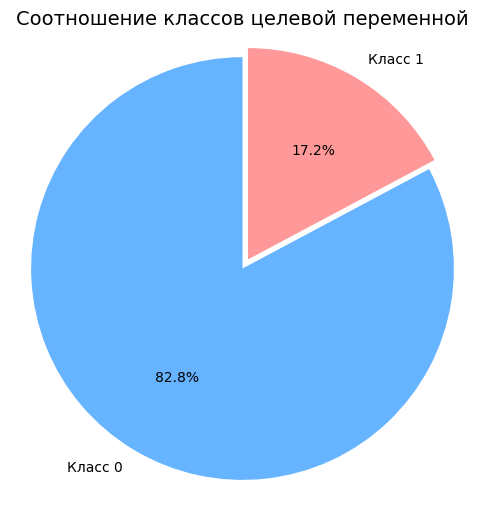

In [41]:
# На баннеры кликнуло примерно 17% пользователей. Наблюдается явный дисбаланс классов. Теперь визуализируем распределение

# Считаем количество значений
counts = df['click'].value_counts()

# Строим круговую диаграмму
plt.figure(figsize=(6, 6))
plt.pie(counts.values,
        labels=['Класс 0', 'Класс 1'],
        autopct='%1.1f%%',  # Показываем проценты
        colors=['#66b3ff', '#ff9999'],
        explode=(0.05, 0),  # Слегка отделяем первый сектор
        startangle=90)

plt.title('Соотношение классов целевой переменной', fontsize=14)
plt.axis('equal')
plt.show()

#### 2.3 Анализ признаков

Исходя из контекста задачи, явно бесполезными являются: id, device_id, device_ip. По остальным признакам необходимо будет провести отбор. 

In [42]:
cat_features = df.select_dtypes(include=['str']).columns.tolist()
print("Категориальные признаки:")
print(cat_features)

df[cat_features].head(5)

Категориальные признаки:
['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'ml_feature_2', 'ml_feature_7']


,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,ml_feature_2,ml_feature_7
0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,A,Z
1,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,C,X
2,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,D,Y
3,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,A,Y
4,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,A,X


In [43]:
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Числовые признаки:")
print(num_features)

df[num_features].head(5)

Числовые признаки:
['id', 'click', 'hour', 'C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']


,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,...,C20,C21,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,1,0,17614,320,50,...,-1,33,-0.996823,0.666588,0,0.817292,0.993275,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1,0,15701,320,50,...,-1,79,-0.391309,5.146789,1,-0.883865,-0.825722,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,1,0,17914,320,50,...,100084,32,-2.112732,7.169348,0,-0.859440,-0.338365,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,1,0,21611,320,50,...,100111,61,0.332707,-0.290708,1,0.062795,0.062934,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1,0,15702,320,50,...,100084,79,1.166623,6.319134,1,-0.675276,0.797144,0.640827,0.297955,-0.136909


In [44]:
# Удалим явно бесполезные признаки

df = df.drop(columns=['id', 'device_id', 'device_ip'])

In [45]:
# Признак hour бесполезен в текущем виде, вместо него предлагаю сделать 2 новых признака: дискретный Время суток 
# и бинарный Выходной или нет. После признак hour удалить 

# Сначала преобразуем hour в строку

df['hour'] = df['hour'].astype(str)

# После преобразуем в datetime объект

df['datetime'] = pd.to_datetime(df['hour'], format='%y%m%d%H')

# Удаляем hour

df = df.drop(columns=['hour'])

# Проверка

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   click             50000 non-null  int64         
 1   C1                50000 non-null  int64         
 2   banner_pos        50000 non-null  int64         
 3   site_id           50000 non-null  str           
 4   site_domain       50000 non-null  str           
 5   site_category     50000 non-null  str           
 6   app_id            50000 non-null  str           
 7   app_domain        50000 non-null  str           
 8   app_category      50000 non-null  str           
 9   device_model      50000 non-null  str           
 10  device_type       50000 non-null  int64         
 11  device_conn_type  50000 non-null  int64         
 12  C14               50000 non-null  int64         
 13  C15               50000 non-null  int64         
 14  C16               50000 non-null 

In [46]:
# Определим время суток из нового столбца datetime и запишем в отдельный

df['time_of_day'] = ''

for idx, time in df['datetime'].items():  
    hour = time.hour
    if 5 <= hour < 12:
        df.loc[idx, 'time_of_day'] = 'Утро'
    elif 12 <= hour < 18:
        df.loc[idx, 'time_of_day'] = 'День'
    elif 18 <= hour < 23:
        df.loc[idx, 'time_of_day'] = 'Вечер'
    else:
        df.loc[idx, 'time_of_day'] = 'Ночь'

In [47]:
# Определим по дате выходной или будний день. Признак сделаем бинарным - Weekend = 0 - будний, 1 - выходной

for idx, time in df['datetime'].items():
    day_of_week_num = time.weekday()
    if 5 <= day_of_week_num < 6:
        df.loc[idx, 'weekend'] = 1
    else:
        df.loc[idx, 'weekend'] = 0

In [48]:
# Проверка

df[['time_of_day', 'weekend']].value_counts()

time_of_day  weekend
Утро         0.0        16338
День         0.0        14398
Ночь         0.0         8380
Вечер        0.0         6705
День         1.0         1679
Утро         1.0         1281
Вечер        1.0          744
Ночь         1.0          475
Name: count, dtype: int64

In [49]:
# Удалим вспомогательную колонку datetime

df_filtered = df.drop(columns=['datetime'])

In [50]:
# Проверка

df_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   click             50000 non-null  int64  
 1   C1                50000 non-null  int64  
 2   banner_pos        50000 non-null  int64  
 3   site_id           50000 non-null  str    
 4   site_domain       50000 non-null  str    
 5   site_category     50000 non-null  str    
 6   app_id            50000 non-null  str    
 7   app_domain        50000 non-null  str    
 8   app_category      50000 non-null  str    
 9   device_model      50000 non-null  str    
 10  device_type       50000 non-null  int64  
 11  device_conn_type  50000 non-null  int64  
 12  C14               50000 non-null  int64  
 13  C15               50000 non-null  int64  
 14  C16               50000 non-null  int64  
 15  C17               50000 non-null  int64  
 16  C18               50000 non-null  int64  
 17  C19 

#### 2.4 Анализ пропущенных значений

Явных пропущенных значений в датасете нет

In [51]:
missing_count = df_filtered.isnull().sum()
print("Количество пропусков по столбцам:")
print(missing_count[missing_count > 0])

Количество пропусков по столбцам:
Series([], dtype: int64)


#### 2.5 Анализ категориальных признаков


In [52]:
# Выведем число уникальных значений в каждом из категориальных признаков

# Обновим категориальные переменные

cat_features = df_filtered.select_dtypes(include=['str']).columns.tolist()

# Посчитаем уникальные значения

df_filtered[cat_features].nunique()

site_id          1160
site_domain      1013
site_category      18
app_id            976
app_domain         67
app_category       22
device_model     2521
ml_feature_2        5
ml_feature_7        3
time_of_day         4
dtype: int64

Часть признаков имеют большое число уникальных значений. Для них не подойдет использование OneHotEncoder. Для кодирования OneHot оставим только признаки с числом уникальных значенйи до 10. Это time_of_day, ml_feature_2 и ml_feature_7. Для других признаков будем применять иные методы, например, TargetEncoder

#### 2.6 Анализ выбросов и распределений

Необходимо проанализировать данные на предмет явных выбросов и вида распределения значений

In [53]:
# Подготовим функцию для определения выбросов методом межквартильного размаха

def detect_outliers_iqr(df, multiplier=1.5):
    # multiplier: множитель IQR (1.5 - умеренные, 3 - экстремальные выбросы)

    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    outliers = (df < lower_bound) | (df > upper_bound)
    
    return outliers, (lower_bound, upper_bound)

In [54]:
# Обновим значение списка числовых признаков
num_features = df_filtered.select_dtypes(include=['int64', 'float64']).columns.tolist()


for col in num_features:
    
    if df_filtered[col].nunique() > 10: # Уберем из поиска выбросов признаки с небольшим количеством уникальных значений
        outliers, (lower_bound, upper_bound) = detect_outliers_iqr(df_filtered[col])
        n_outliers = outliers.sum()
        pct_outliers = round((n_outliers / len(df_filtered[col])) * 100, 2)
        print(f"В столбце {col} найдено {n_outliers} выбросов, что составляет {pct_outliers} %")
    else: 
        pass


В столбце C14 найдено 4170 выбросов, что составляет 8.34 %
В столбце C17 найдено 4224 выбросов, что составляет 8.45 %
В столбце C19 найдено 9015 выбросов, что составляет 18.03 %
В столбце C20 найдено 0 выбросов, что составляет 0.0 %
В столбце C21 найдено 379 выбросов, что составляет 0.76 %
В столбце ml_feature_1 найдено 347 выбросов, что составляет 0.69 %
В столбце ml_feature_3 найдено 0 выбросов, что составляет 0.0 %
В столбце ml_feature_5 найдено 360 выбросов, что составляет 0.72 %
В столбце ml_feature_6 найдено 0 выбросов, что составляет 0.0 %
В столбце ml_feature_8 найдено 0 выбросов, что составляет 0.0 %
В столбце ml_feature_9 найдено 387 выбросов, что составляет 0.77 %
В столбце ml_feature_10 найдено 352 выбросов, что составляет 0.7 %


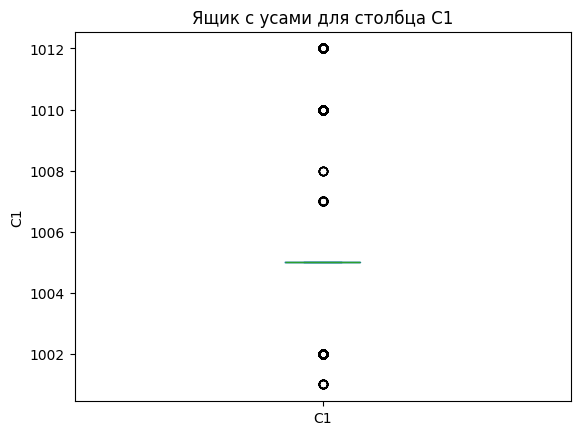

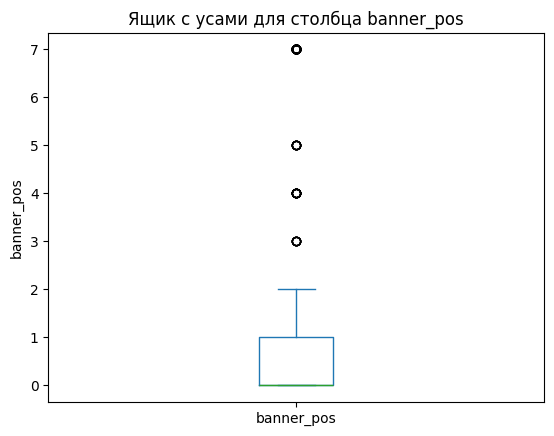

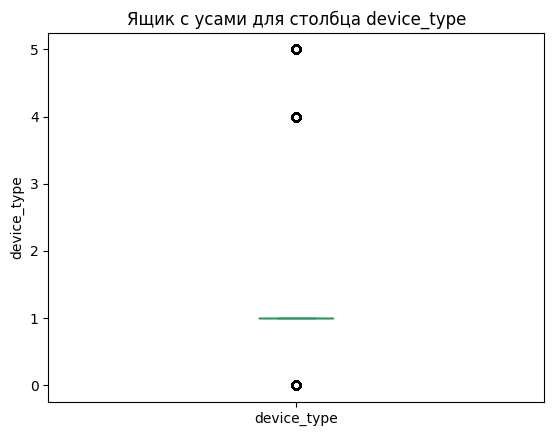

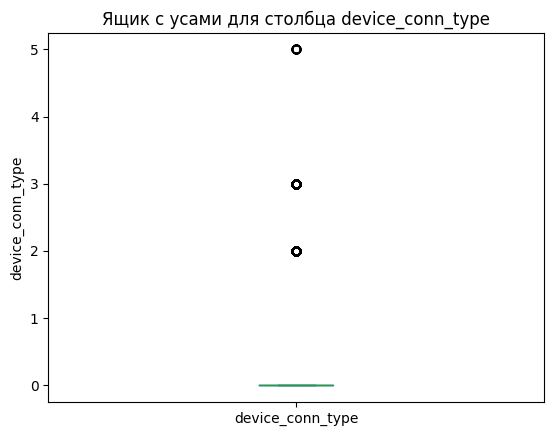

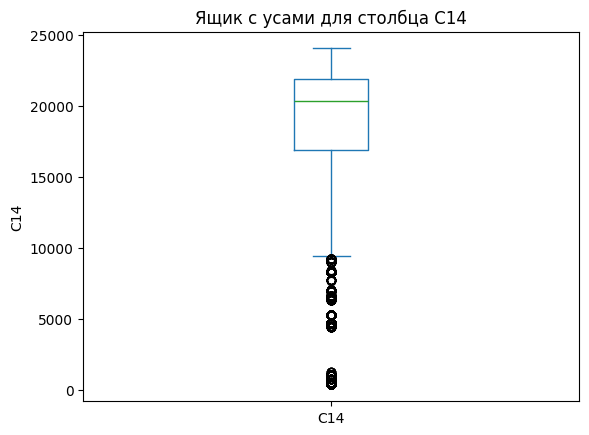

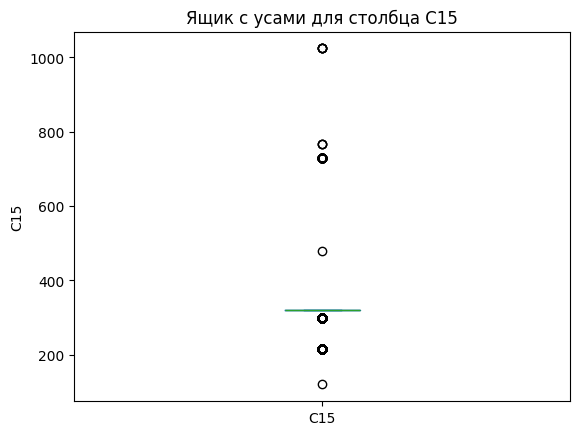

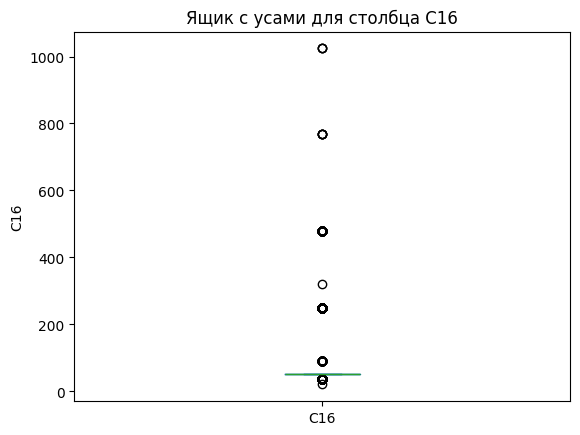

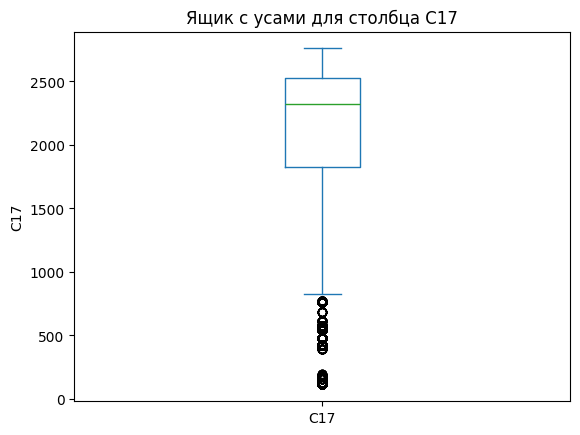

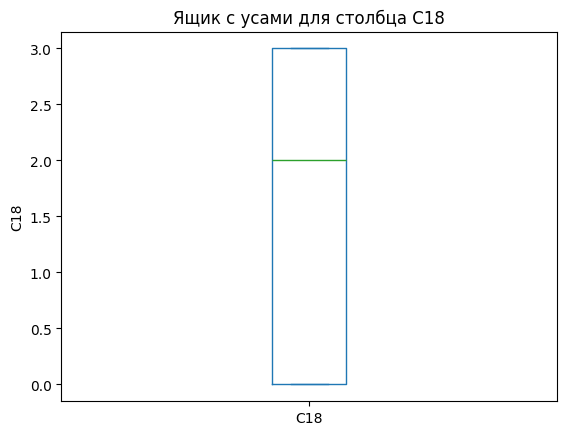

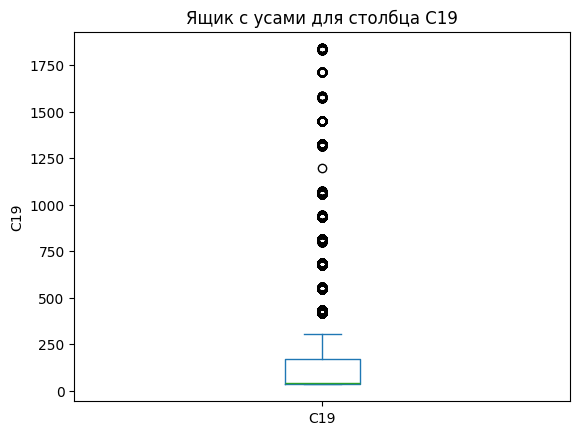

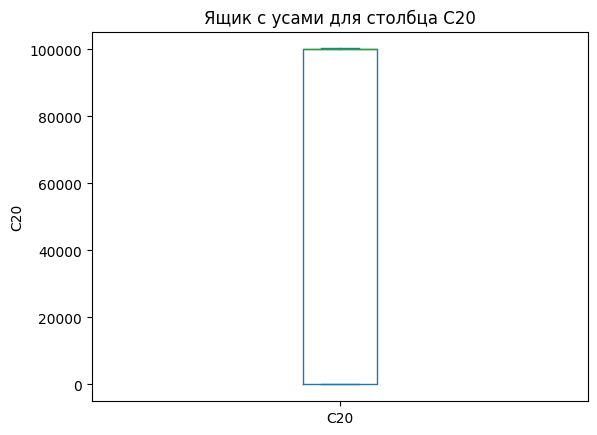

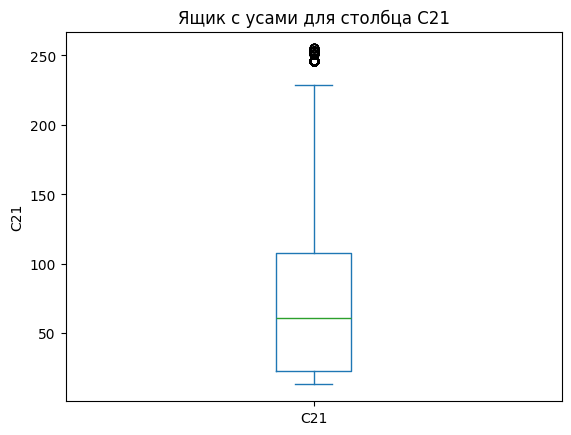

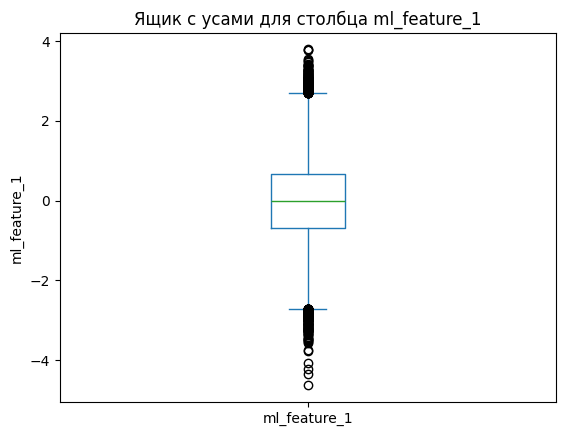

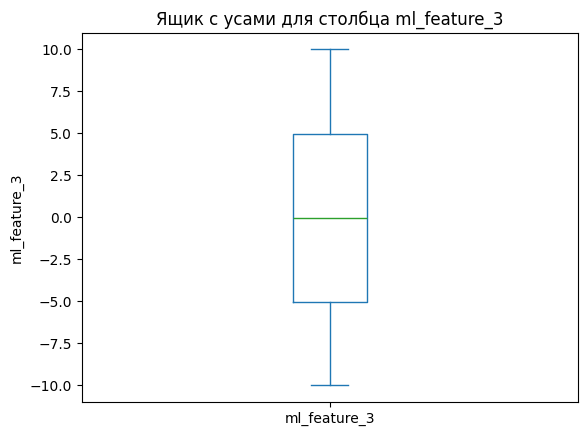

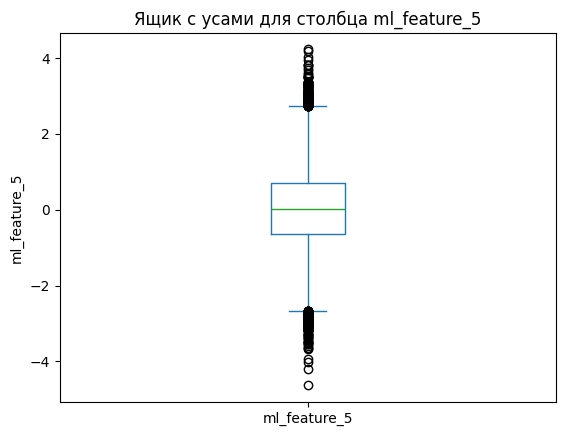

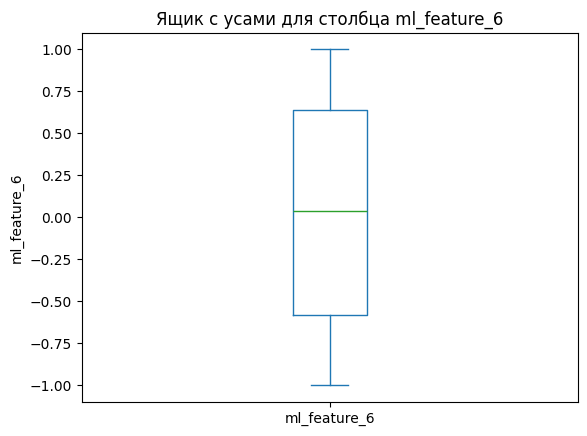

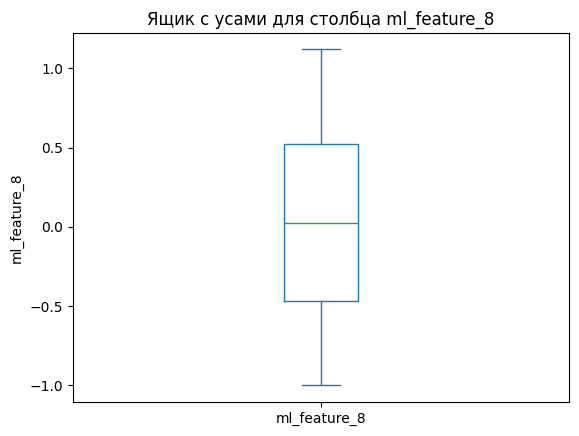

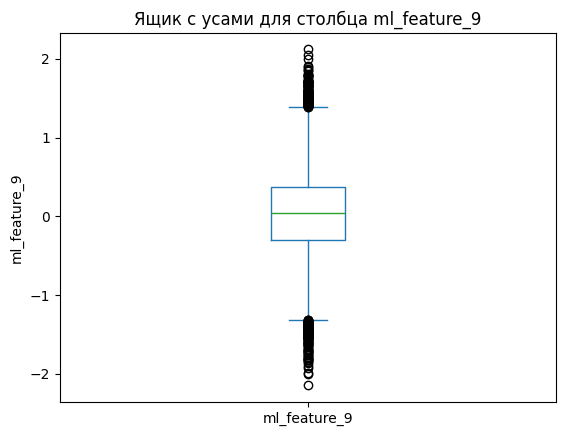

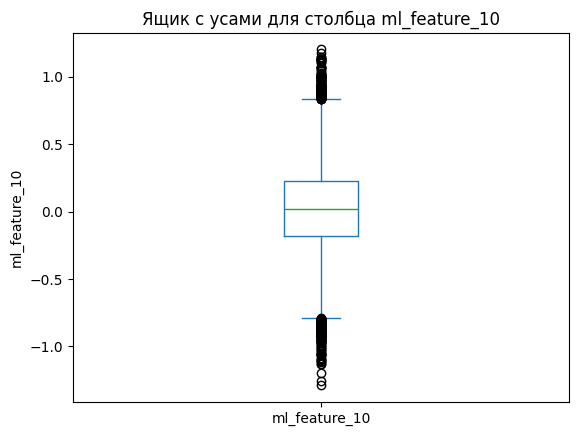

In [55]:
# Визуализируем распределение и выбросы

for col in num_features:
    if df_filtered[col].nunique() > 2: # Убираем бинарные признаки
        df_filtered[col].plot(kind='box')
        plt.title(f"Ящик с усами для столбца {col}")
        plt.ylabel(f"{col}")
        plt.show()
    else:
        pass

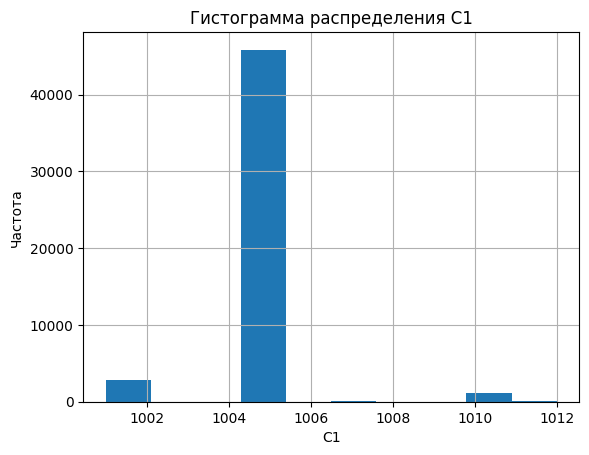

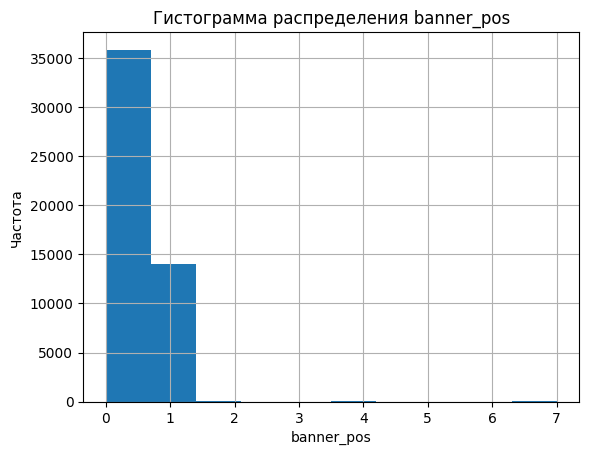

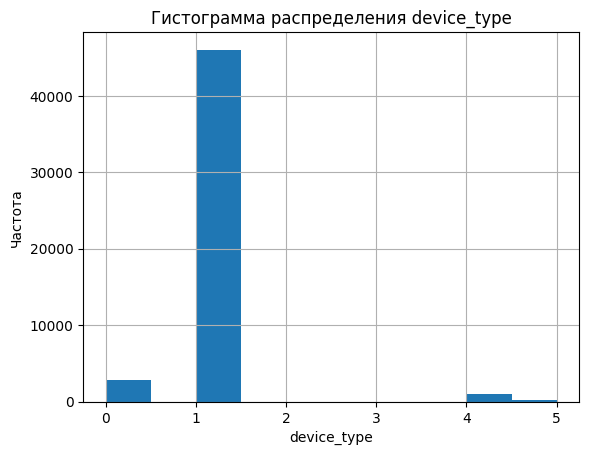

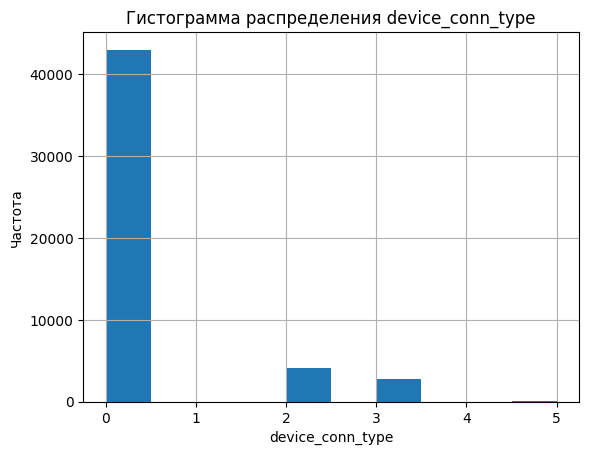

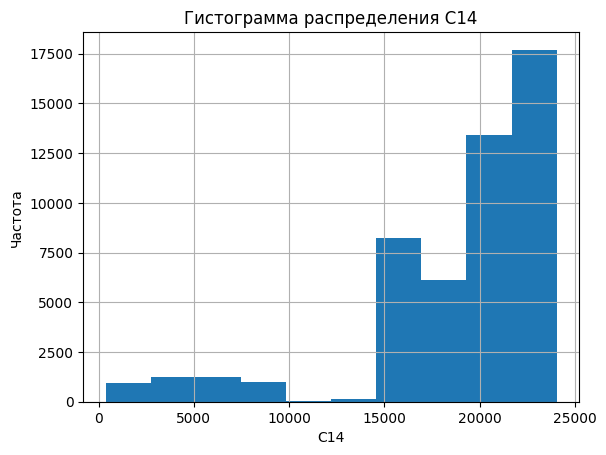

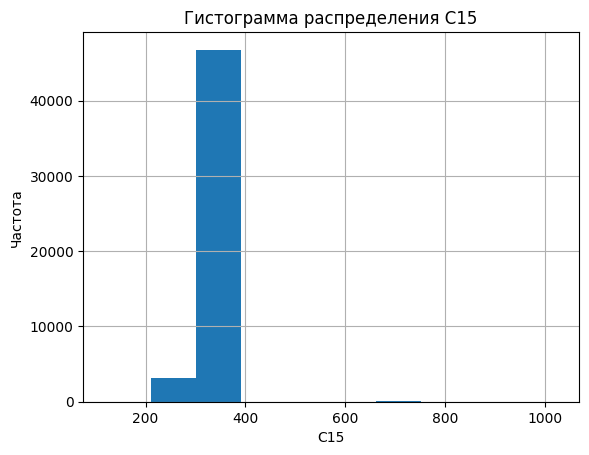

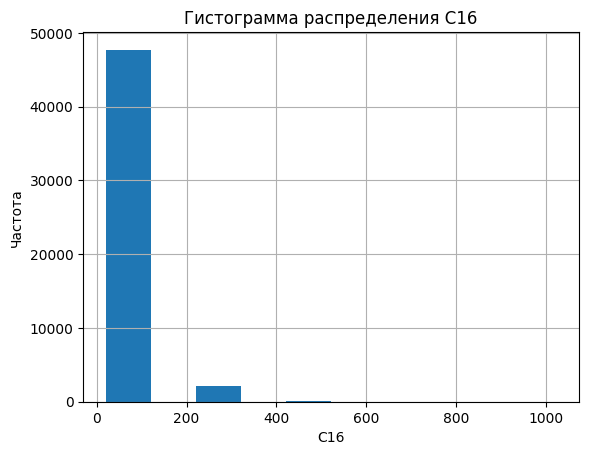

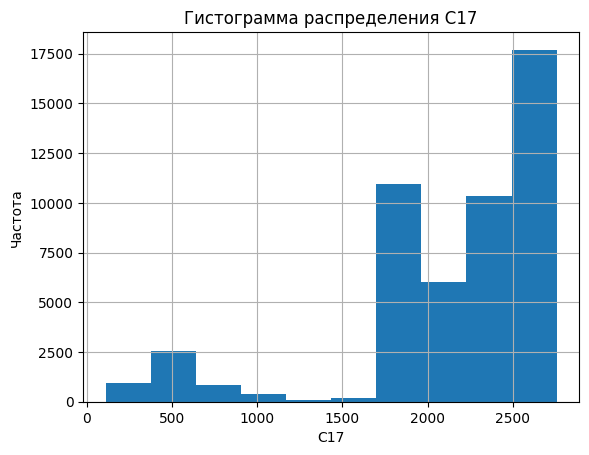

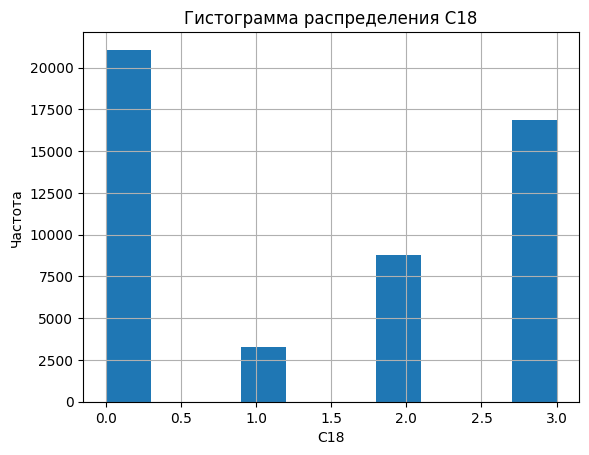

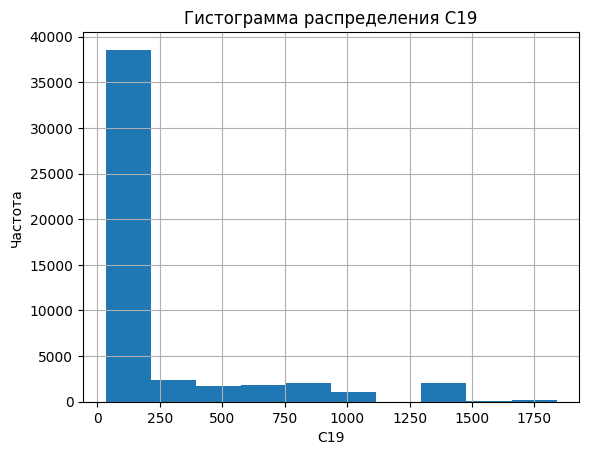

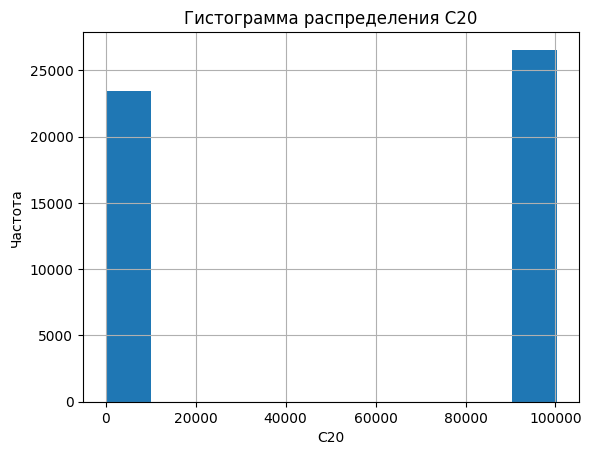

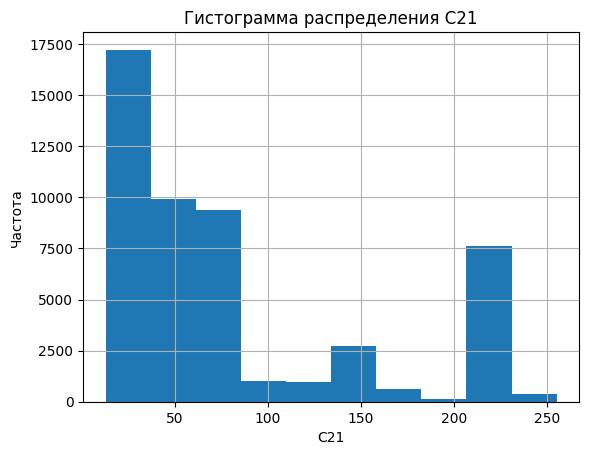

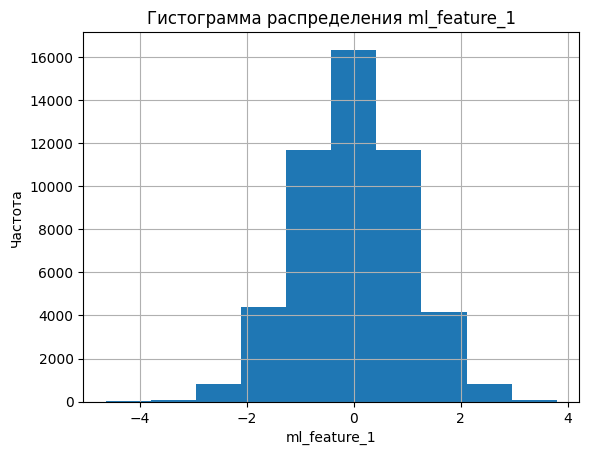

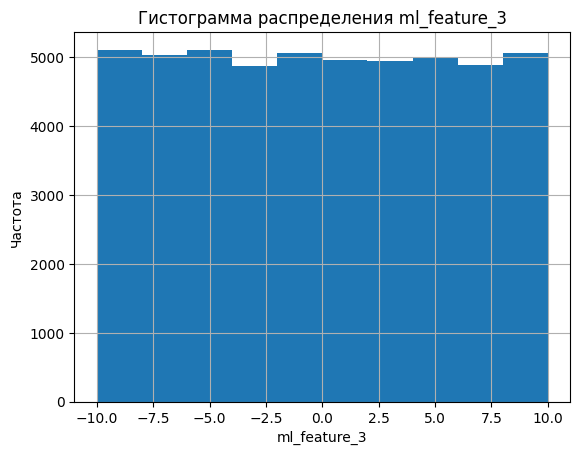

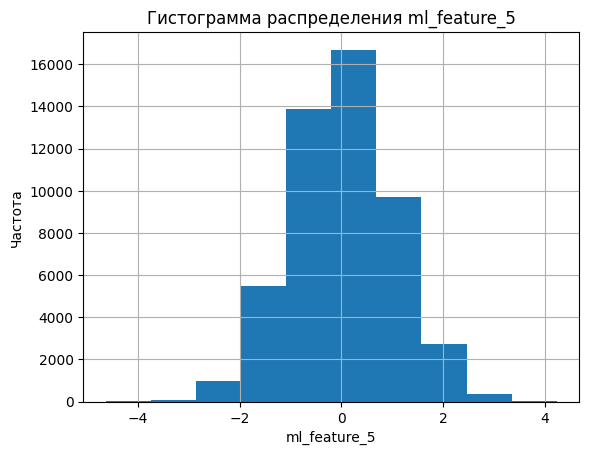

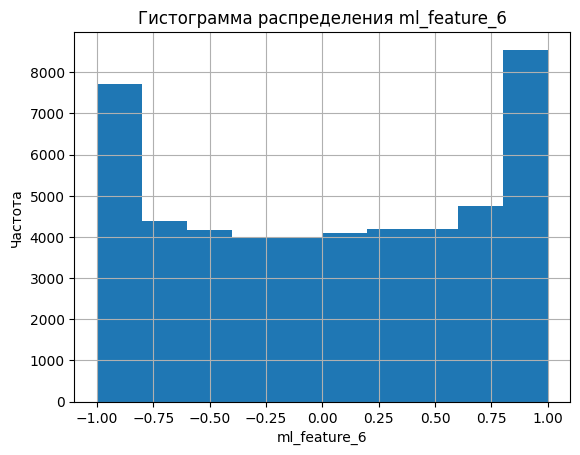

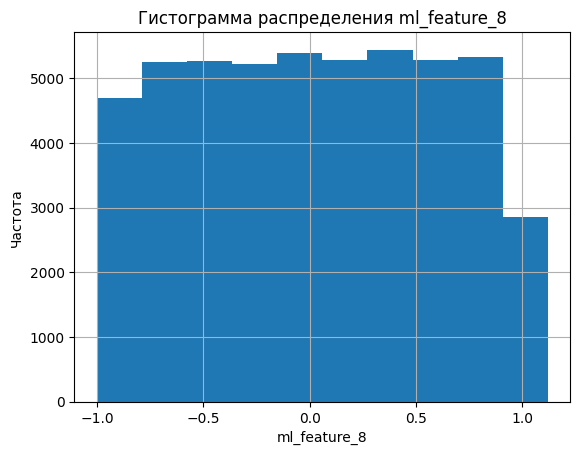

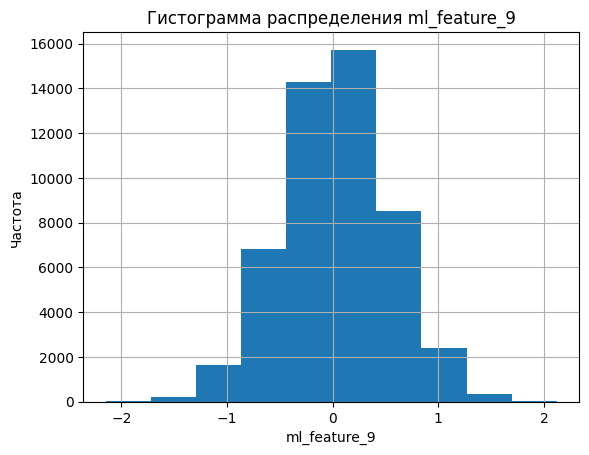

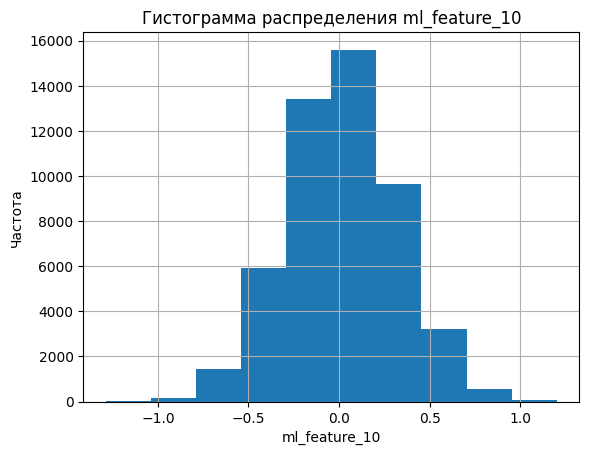

<Figure size 640x480 with 0 Axes>

In [56]:
# Также построим гистограммы для проверки нормальности распределения

for col in num_features:
    if df_filtered[col].nunique() > 2: # Убираем бинарные признаки
        df_filtered[col].hist()
        plt.title(f"Гистограмма распределения {col}")
        plt.xlabel(f"{col}")
        plt.ylabel('Частота')
        plt.show()

plt.tight_layout()
plt.show()

По части признаков распределение нормальное, по части асимметричное

#### 2.7 Корреляции

Для выявления корелляций построим матрицу корелляции хи-квадрат для 

In [57]:
# Напишем функцию определения интервальных признаков для матрицы хи-квадрат
# За порог "непрерывности" возьмем 50 уникальных значений

def estimate_interval_cols_alternative(df, unique_threshold=50):
    
    interval_cols = []
    
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            n_unique = df[col].nunique()
            
            if n_unique > unique_threshold:
                interval_cols.append(col)
    
    return interval_cols

/Users/mymensk/ya_project/ml-env/lib/python3.13/site-packages/phik/bivariate.py:255: UserWarning: Many cells: 2460496. Are interval variables set correctly?
  warnings.warn(
/Users/mymensk/ya_project/ml-env/lib/python3.13/site-packages/phik/bivariate.py:255: UserWarning: Many cells: 2924360. Are interval variables set correctly?
  warnings.warn(
/Users/mymensk/ya_project/ml-env/lib/python3.13/site-packages/phik/bivariate.py:255: UserWarning: Many cells: 2553773. Are interval variables set correctly?
  warnings.warn(


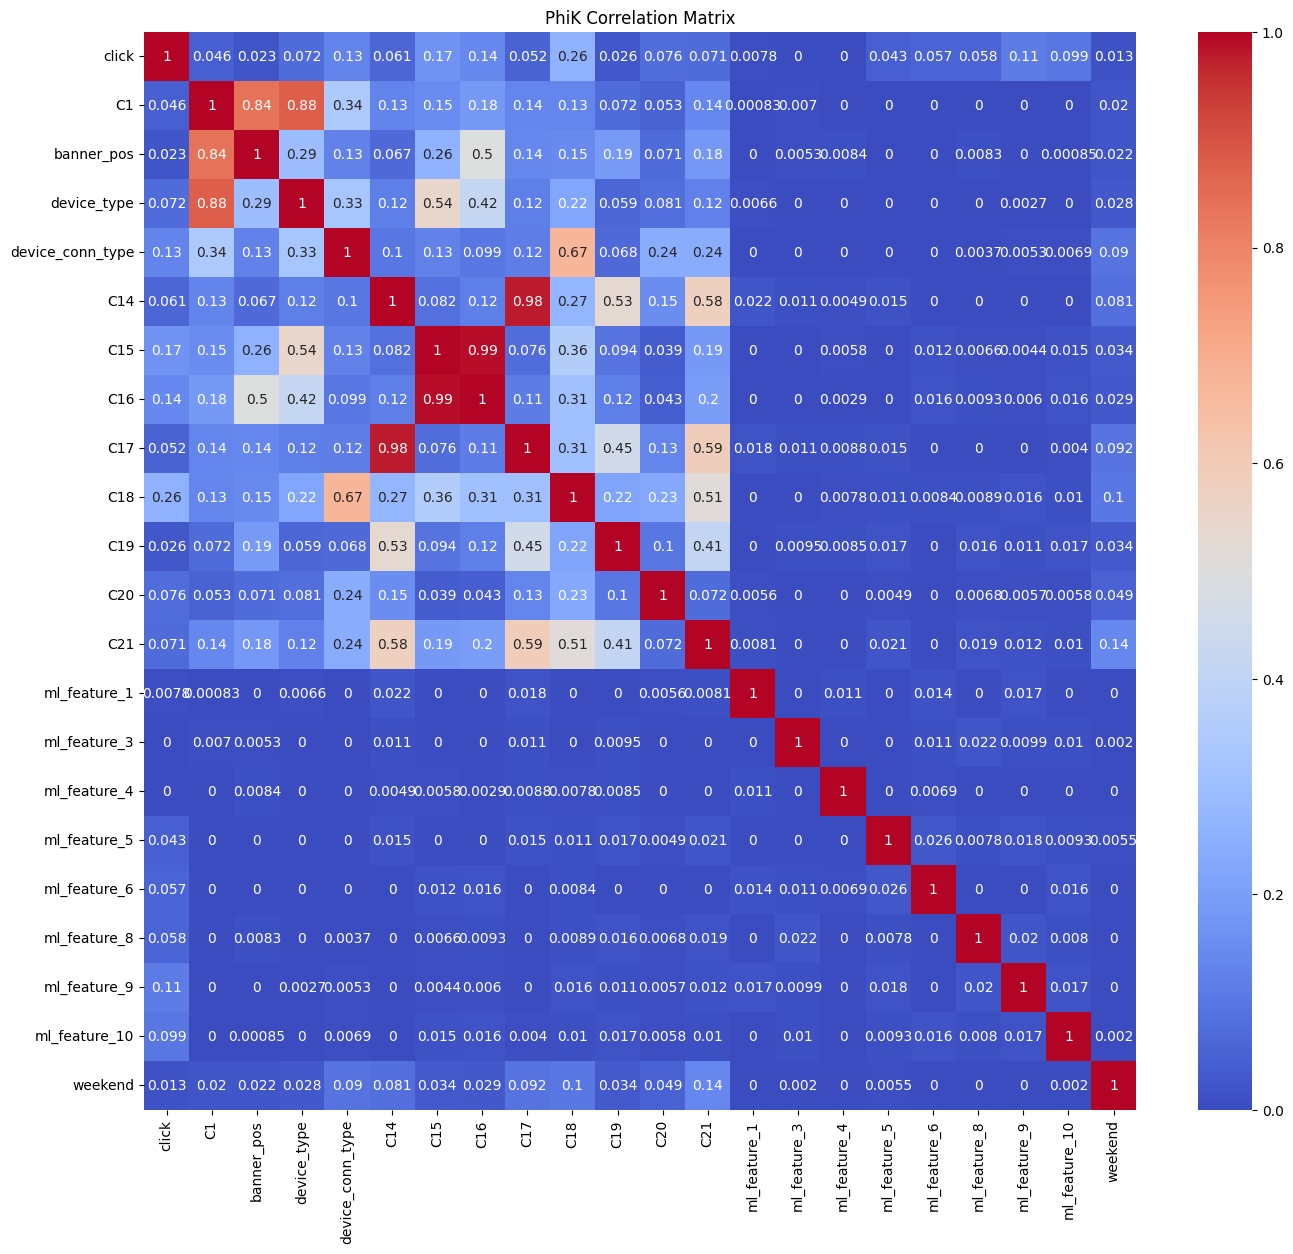

In [58]:
# Построим матрицу, предварительно отобрав колонки для параметра interval_cols

interval_cols = estimate_interval_cols_alternative(df_filtered)

corr_matrix = df_filtered.phik_matrix(bins=5, interval_cols = interval_cols)

corr_matrix_filtered = corr_matrix.loc[num_features, num_features]

plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix_filtered, annot=True, cmap='coolwarm')
plt.title('PhiK Correlation Matrix')
plt.show()

Из матрицы корелляции можно сделать вывод, что сильно кореллируют между собой признаки: 
C15 и C16 - коэффициент 0.99,
С14 и С17 - коэфициент 0.98,
С1 и banner_position - коэффициент 0.84,
С1 и device_type - коэффициент 0.88

Удалим по одному признаку из каждой пары - С16, С17 и С1.

In [59]:
df_filtered = df_filtered.drop(columns=['C1', 'C16', 'C17'])

In [60]:
df_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   click             50000 non-null  int64  
 1   banner_pos        50000 non-null  int64  
 2   site_id           50000 non-null  str    
 3   site_domain       50000 non-null  str    
 4   site_category     50000 non-null  str    
 5   app_id            50000 non-null  str    
 6   app_domain        50000 non-null  str    
 7   app_category      50000 non-null  str    
 8   device_model      50000 non-null  str    
 9   device_type       50000 non-null  int64  
 10  device_conn_type  50000 non-null  int64  
 11  C14               50000 non-null  int64  
 12  C15               50000 non-null  int64  
 13  C18               50000 non-null  int64  
 14  C19               50000 non-null  int64  
 15  C20               50000 non-null  int64  
 16  C21               50000 non-null  int64  
 17  ml_f

#### 2.8 Выводы по EDA

В рамках разведочного анализа удалось выяснить, что в представленной выборке 50  000 строк, в которых нет пропусков. 
Выявлено несколько сильно кореллирующих между собой признаков, из каждой пары был удален один признак. Также было найдено несколько признаков, которые не имеют смысла в контексте данной задачи, они также были удалены. 

Был доработан не имеющий смысла в чистом виде признак hour, вместо него появились два новых: Выходной (да/нет) и время суток, которые потенциально могут влиять на вероятность клика

В ряде категориальных признаков обнаружено большое количество уникальных значений, для них необходимо будет настроить Target Encoder.

С целевой переменной больше всего кореллируют два признака: С15 и С18, они выглядят перспективно в рамках модели.

В качестве предобработки необходимо будет создать масштабирующий и кодирующий обработчики и применить их к признакам.
Так как признаков много, придется провести цикл по Отбору признаков

## 3. Разделение данных на выборки

#### 3.1 Разделите данные

#### 3.2 Проверьте разделение

In [61]:
# Разделим нашу выборку на 2 части. Сначала отделим целевую переменную, после разделим 80/20 с сохранением баланса классов

X = df_filtered.drop(columns=['click'])
y = df_filtered['click']

X_train_val_calib, X_test, y_train_val_calib, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

X_test.shape[0]

10000

In [62]:
# Теперь отделим 10% от обучающей выборки для целей калибровки модели

X_train_val, X_calib, y_train_val, y_calib = train_test_split(
    X_train_val_calib, y_train_val_calib, test_size=0.1, stratify=y_train_val_calib, random_state=RANDOM_STATE
)

In [63]:
# Проверим разбивку по целевой переменной


print(f"В обучающей выборке признаков {X_train_val.shape[0]} значений")
print(f"В калибровочной выборке признаков {X_calib.shape[0]} значений")
print(f"В тестовой выборке тестовых признаков {X_test.shape[0]} значений")

print(f"В обучающей выборке по целевой переменной {y_train_val.shape[0]} значений: {y_train_val.value_counts(normalize=True)}")
print(f"В калибровочной выборке по целевой переменной {y_calib.shape[0]} значений: {y_calib.value_counts(normalize=True)}")
print(f"В тестовой выборке по целевой переменной {y_test.shape[0]} значений: {y_test.value_counts(normalize=True)}")

В обучающей выборке признаков 36000 значений
В калибровочной выборке признаков 4000 значений
В тестовой выборке тестовых признаков 10000 значений
В обучающей выборке по целевой переменной 36000 значений: click
0    0.827944
1    0.172056
Name: proportion, dtype: float64
В калибровочной выборке по целевой переменной 4000 значений: click
0    0.828
1    0.172
Name: proportion, dtype: float64
В тестовой выборке по целевой переменной 10000 значений: click
0    0.8279
1    0.1721
Name: proportion, dtype: float64


Выборки разделены, пропорция по классам целевой переменной соблюдена

## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

#### 4.2 Объедините пайплайны

####  4.1 Пайплайн для предобработки данных

Подготовим пайплайны для обработки данных: для числовых и для категориальных

In [64]:
# Числовые признаки

num_features = X_train_val.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(num_features)

['banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'weekend']


In [65]:
# Категориальные признаки

cat_features = X_train_val.select_dtypes(include=['str']).columns.tolist()
print(cat_features)

['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_model', 'ml_feature_2', 'ml_feature_7', 'time_of_day']


In [66]:
# Разделим категориальные признаки на высококардиальные (для TargetEncoder) и низкокардиальные (для OneHotEncoder)

cat_high_features = []
cat_low_features = []

for col in cat_features:
    if X_train_val[col].nunique() > 10:
        cat_high_features.append(col)
    else:
        cat_low_features.append(col)

print(f"Высококардиальные признаки: {cat_high_features}")

print(f"Низкокардиальные признаки: {cat_low_features}")

Высококардиальные признаки: ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_model']
Низкокардиальные признаки: ['ml_feature_2', 'ml_feature_7', 'time_of_day']


In [67]:
# Масштабирование числовых признаков
num_scaler = StandardScaler()

# Кодирование низкокардиальных категориальных признаков. Удаление первой колонки для избежания Dummy ловушки
cat_low_encoder = OneHotEncoder(handle_unknown='ignore', min_frequency=0.01, sparse_output=False, drop='first') 

# Кодирование высококардиальных категориальных признаков
cat_high_encoder = TargetEncoder(smooth='auto', shuffle=True, random_state=RANDOM_STATE) 

#### 4.2 Подготовка общего пайплайна для обработки данных

Подготовим пайплайны для обработки числовых и категориальных значений. Соберем их в единый трансформер

In [68]:
num_pipeline = Pipeline(steps=[
                  ('scale_nums', num_scaler)      
])

cat_low_pipeline = Pipeline(steps=[
                   ('cat_low_encoder', cat_low_encoder)   
])

cat_high_pipeline = Pipeline(steps=[
                   ('cat_high_encoder', cat_high_encoder)   
])

preprocessor = ColumnTransformer(
                   transformers=[
                       ('num_pipeline', num_pipeline, num_features),
                       ('cat_low_pipeline', cat_low_pipeline, cat_low_features),
                       ('cat_high_pipeline', cat_high_pipeline, cat_high_features)                    
    ]
)

## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы

#### 5.2 Примените методы-обёртки

#### 5.3 Выберите финальный набор признаков

#### 5.1 Фильтрационные методы

В рамках разведочного анализа были удалены признаки:  С16, С17 и С1 - которые были выявлены с помощью матрицы корелляции Phik.

In [69]:
# Проверим наши данные на наличие числовых константных признаков. Категориальных константных в выборке нет 
# Выше был приведен подсчет уникальных значений в категориальных признаках

numerical_data = X_train_val[num_features]

# Обучаем VarianceThreshold
vs_constant = VarianceThreshold(threshold=0.0) 
vs_constant.fit(numerical_data)

# Находим константные числовые признаки
constant_num_columns = [col for col, keep in zip(num_features, vs_constant.get_support()) if not keep] 
print(constant_num_columns)

[]


Категориальных и числовых константных признаков в выборке нет. Теперь проверим наличие признаков с низкой вариацией (квази-константных) - когда одинаковое значение занимает подавляющее большинство записей. Установим VarianceThreshold = 0.1

In [70]:
# Устанавливаем значение переменной 

vs_quasi = VarianceThreshold(threshold=0.1) 
vs_quasi.fit(numerical_data)
quasi_num_cols = [col for col, keep in zip(num_features, vs_quasi.get_support()) if not keep]

quasi_cat_cols = [col for col in X_train_val.select_dtypes(include=['str']).columns
                  if X_train_val[col].value_counts(normalize=True).iloc[0] > 0.9]

print(f"Квази-константные числовые признаки: {quasi_num_cols}")
print(f"Квази-константные категориальные признаки: {quasi_cat_cols}")


Квази-константные числовые признаки: ['ml_feature_10', 'weekend']
Квази-константные категориальные признаки: []


Признак 'weekend' является бинарным, потому удалять его не будем, объективно, что выходных меньше, чем будних дней. Признак 'ml_feature_10' в дальнейшем можно удалить

#### 5.2 Методы-обёртки

Перейдем к методам-оберткам для определения "лишних" признаков в нашем датасете.
Применим оптимальный с точки зрения компромиссов к вычислительным затратам метод рекурсивного исключения признаков. В качестве модели для отбора применим логистическую регрессию

In [71]:
# Применим обработку признаков для обучающей выборки
    
processed_data = preprocessor.fit_transform(X_train_val, y_train_val)

# Подготовим название признаков после препроцессора
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num_pipeline__banner_pos' 'num_pipeline__device_type'
 'num_pipeline__device_conn_type' 'num_pipeline__C14' 'num_pipeline__C15'
 'num_pipeline__C18' 'num_pipeline__C19' 'num_pipeline__C20'
 'num_pipeline__C21' 'num_pipeline__ml_feature_1'
 'num_pipeline__ml_feature_3' 'num_pipeline__ml_feature_4'
 'num_pipeline__ml_feature_5' 'num_pipeline__ml_feature_6'
 'num_pipeline__ml_feature_8' 'num_pipeline__ml_feature_9'
 'num_pipeline__ml_feature_10' 'num_pipeline__weekend'
 'cat_low_pipeline__ml_feature_2_B' 'cat_low_pipeline__ml_feature_2_C'
 'cat_low_pipeline__ml_feature_2_D' 'cat_low_pipeline__ml_feature_2_E'
 'cat_low_pipeline__ml_feature_7_Y' 'cat_low_pipeline__ml_feature_7_Z'
 'cat_low_pipeline__time_of_day_День' 'cat_low_pipeline__time_of_day_Ночь'
 'cat_low_pipeline__time_of_day_Утро' 'cat_high_pipeline__site_id'
 'cat_high_pipeline__site_domain' 'cat_high_pipeline__site_category'
 'cat_high_pipeline__app_id' 'cat_high_pipeline__app_domain'
 'cat_high_pipeline__app_category' 'cat_hi

In [72]:
# Выберем модель для отбора признаков - Логистическая регрессия. Отберем 20 признаков

estimator = LogisticRegression(solver='liblinear')

# Иницилизация селектора
rfe_selector = RFE(estimator, n_features_to_select=20, step=1)

rfe_selector.fit(processed_data, y_train_val)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegre...r='liblinear')
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",20
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True


In [73]:
# Получаем ранг важности каждого признака (1 - самый важный)

feature_ranking = rfe_selector.ranking_ 

result = pd.DataFrame({
    'Признак': feature_names,
    'Рейтинг': feature_ranking
})

print(result.sort_values(by='Рейтинг'))

                               Признак  Рейтинг
16         num_pipeline__ml_feature_10        1
31       cat_high_pipeline__app_domain        1
30           cat_high_pipeline__app_id        1
29    cat_high_pipeline__site_category        1
28      cat_high_pipeline__site_domain        1
27          cat_high_pipeline__site_id        1
26  cat_low_pipeline__time_of_day_Утро        1
25  cat_low_pipeline__time_of_day_Ночь        1
24  cat_low_pipeline__time_of_day_День        1
23    cat_low_pipeline__ml_feature_7_Z        1
22    cat_low_pipeline__ml_feature_7_Y        1
19    cat_low_pipeline__ml_feature_2_C        1
32     cat_high_pipeline__app_category        1
15          num_pipeline__ml_feature_9        1
33     cat_high_pipeline__device_model        1
13          num_pipeline__ml_feature_6        1
12          num_pipeline__ml_feature_5        1
2       num_pipeline__device_conn_type        1
3                    num_pipeline__C14        1
14          num_pipeline__ml_feature_8  

Реализуем также отбор признаков тремя разными функциями, для сравнения с самым быстрым RFE и сравним полученный набор признаков 

In [74]:
# Подготовим функцию для отбора признаков

def wrapper_selection(method_name, estimator, X, y, feature_names, k=(1, 10), forward=True, rfe_k=None):
    start_time = datetime.datetime.now()
    if method_name == 'RFE':
        selector = RFE(estimator, n_features_to_select=rfe_k)
        selector.fit(X, y)
        selected_idx = selector.support_
    else:
        selector = SFS(estimator, k_features=k, forward=forward, scoring=scoring_metric, cv=None, n_jobs=-1)
        selector.fit(X, y)
        selected_idx = list(selector.k_feature_idx_)

    elapsed = datetime.datetime.now() - start_time
    selected_features = np.array(feature_names)[selected_idx]
    return selected_features, elapsed

# Соберем пайплайн

def build_pipeline(selected_features, method_name):
    feature_names_all = list(preprocessor.get_feature_names_out())
    selected_indices = [feature_names_all.index(f) for f in selected_features]

    selector = FunctionTransformer(lambda X: X[:, selected_indices], validate=False)

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('selector', selector),
        ('model', SVC(probability=True, random_state=42))
    ])

    score = cross_val_score(pipeline, X, y, scoring='accuracy', cv=cv_splitter, n_jobs=-1).mean()
    return pipeline, score


# Определим методы отбора признаков с помощью Логистической регрессии и методом опорных векторов

lr_estimator = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
svc_evaluator = SVC(probability=True, random_state=RANDOM_STATE)
cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring_metric = 'accuracy'


# Запуск всех 3 методов отбора

forward_features, forward_time = wrapper_selection('SFS', lr_estimator, processed_data, y_train_val, feature_names, k=(1, 20), forward=True)

backward_features, backward_time = wrapper_selection('SFS', lr_estimator, processed_data, y_train_val, feature_names, k=(1, 20), forward=False)

rfe_features, rfe_time = wrapper_selection('RFE', lr_estimator, processed_data, y_train_val, feature_names, rfe_k=20)


# Построим финальные пайплайны

final_pipelines = {}
final_scores = {}

final_pipelines['Forward'], final_scores['Forward'] = build_pipeline(forward_features, 'Forward Selection')

final_pipelines['Backward'], final_scores['Backward'] = build_pipeline(backward_features, 'Backward Elimination')

final_pipelines['RFE'], final_scores['RFE'] = build_pipeline(rfe_features, 'RFE')


# Соберем результаты

methods = [
    ('Forward Selection', forward_features, forward_time, final_scores['Forward']),
    ('Backward Elimination', backward_features, backward_time, final_scores['Backward']),
    ('RFE', rfe_features, rfe_time, final_scores['RFE'])
]

# Создание DataFrame сразу из списка кортежей
results_df = pd.DataFrame([
    {'Method': name, 'Features Count': len(features), 'Time (s)': t, 'Pipeline Accuracy': score}
    for name, features, t, score in methods
])

results_df['Pipeline Accuracy'] = results_df['Pipeline Accuracy'].map('{:.4f}'.format)
results_df['Time (s)'] = results_df['Time (s)'].dt.total_seconds().map('{:.2f}'.format)

print("\n=== Сводная Таблица Результатов ===")
print(results_df.to_string(index=False))

# Лучшая стратегия
best_method = results_df.sort_values('Pipeline Accuracy', ascending=False).iloc[0]['Method']
print(f"\n Лучшая стратегия: {best_method}")

# Печать выбранных признаков для каждого метода
for name, features, _, _ in methods:
    print(f"\n Выбрано признаков {name}: {len(features)}")
    print(" Список выбранных признаков:")
    print("  • " + "\n  • ".join(features))


=== Сводная Таблица Результатов ===
              Method  Features Count Time (s) Pipeline Accuracy
   Forward Selection              19     6.22            0.8297
Backward Elimination              17    13.60            0.8286
                 RFE              20     0.69            0.8298

 Лучшая стратегия: RFE

 Выбрано признаков Forward Selection: 19
 Список выбранных признаков:
  • num_pipeline__banner_pos
  • num_pipeline__device_type
  • num_pipeline__C15
  • num_pipeline__C18
  • num_pipeline__C21
  • num_pipeline__ml_feature_3
  • num_pipeline__ml_feature_4
  • num_pipeline__ml_feature_5
  • num_pipeline__ml_feature_8
  • num_pipeline__ml_feature_9
  • num_pipeline__ml_feature_10
  • num_pipeline__weekend
  • cat_low_pipeline__ml_feature_2_D
  • cat_low_pipeline__ml_feature_2_E
  • cat_low_pipeline__ml_feature_7_Y
  • cat_low_pipeline__ml_feature_7_Z
  • cat_high_pipeline__site_id
  • cat_high_pipeline__site_category
  • cat_high_pipeline__app_id

 Выбрано признаков Backward

Можно сделать вывод, что RFE отлично справился, и результат его практически совпал с более "жадными" и медленными методами. Набор отобранных признаков совпадает, но Forward Selection отобрал чуть меньшее их число

#### 5.3 Финальный набор признаков

Исходя из результатов ручной фильтрации по квази-константным признаком, принимаем решение оставить 16: 17 из RFE и удалим из этой выборки квази-константный num_pipeline__ml_feature_10

In [77]:
# Сформируем список признаков для дальнейшей работы

columns_to_select = [
'C14',
'ml_feature_5',
'ml_feature_6',
'ml_feature_8',
'ml_feature_9',
'ml_feature_10',
'ml_feature_2',
'ml_feature_7',
'time_of_day',
'site_id',
'site_domain',
'site_category',
'app_id',
'app_domain',
'app_category',
'device_model'
]

# Отфильтруем обучающую и тестовую выборки

X_train_val_fin = X_train_val[columns_to_select]
X_calib_fin = X_calib[columns_to_select]
X_test_fin = X_test[columns_to_select]

# Проверка
X_train_val_fin.info()

<class 'pandas.DataFrame'>
Index: 36000 entries, 41983 to 1762
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   C14            36000 non-null  int64  
 1   ml_feature_5   36000 non-null  float64
 2   ml_feature_6   36000 non-null  float64
 3   ml_feature_8   36000 non-null  float64
 4   ml_feature_9   36000 non-null  float64
 5   ml_feature_10  36000 non-null  float64
 6   ml_feature_2   36000 non-null  str    
 7   ml_feature_7   36000 non-null  str    
 8   time_of_day    36000 non-null  str    
 9   site_id        36000 non-null  str    
 10  site_domain    36000 non-null  str    
 11  site_category  36000 non-null  str    
 12  app_id         36000 non-null  str    
 13  app_domain     36000 non-null  str    
 14  app_category   36000 non-null  str    
 15  device_model   36000 non-null  str    
dtypes: float64(5), int64(1), str(10)
memory usage: 4.7 MB


## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`

### 6.2 Обучите `LogisticRegression`

### 6.3 Обучите `SVC`

### 6.4 Сравните модели

In [78]:
# Сконфигурируем общий кросс-валидатор

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

In [79]:
# После фильтрации признаков переопределим наборы колонок и препроцессор

# Числовые признаки
num_features = X_train_val_fin.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Категориальные признаки
cat_features = X_train_val_fin.select_dtypes(include=['str']).columns.tolist()

# Разделяем на высоко и низкокардиальыне
cat_high_features = []
cat_low_features = []

for col in cat_features:
    if X_train_val_fin[col].nunique() > 10:
        cat_high_features.append(col)
    else:
        cat_low_features.append(col)

# Переопределяем препроцессор 
preprocessor = ColumnTransformer(
                   transformers=[
                       ('num_pipeline', num_pipeline, num_features),
                       ('cat_low_pipeline', cat_low_pipeline, cat_low_features),
                       ('cat_high_pipeline', cat_high_pipeline, cat_high_features)                    
    ]
)

#### 6.1 DummyClassifier

В качестве baseline модели используем DummyClassifier со стратегией 'stratified' (предсказание в пропорции целевой переменной)

In [80]:
# Подготовим функцию для ручного расчета и кросс валидации

def get_baseline_pr_auc(X, y, preprocessor, n_folds=5, random_state=42):
    def pr_auc(y_true, y_pred):
        precision, recall, _ = precision_recall_curve(y_true, y_pred)
        return auc(recall, precision)
    
    # Подготовка
    y_int = y.astype(int)
    
    # Модель
    dummy = DummyClassifier(strategy='stratified', random_state=random_state)
    pipeline = Pipeline([("model", dummy)])
    
    # Ручная кросс-валидация
    scores = []
    for train_idx, val_idx in cv.split(X, y_int):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y_int.iloc[train_idx], y_int.iloc[val_idx]
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict_proba(X_val)[:, 1]
        
        scores.append(pr_auc(y_val, y_pred))
    
    return {
        'scores': np.array(scores),
        'mean': np.mean(scores),
        'std': np.std(scores)
    }

# Вызываем с нашими данными:
baseline = get_baseline_pr_auc(X_train_val_fin, y_train_val, preprocessor)
print(f"Baseline PR-AUC: {baseline['mean']:.4f} (+/- {baseline['std']:.4f})")

Baseline PR-AUC: 0.2407 (+/- 0.0075)


#### 6.2 LogisticRegression

Далее подготовим пайплайн и обучим модель логистической регрессии

In [89]:

# Подготовка данных
y_int = y_train_val.astype(int)

# Создаем пайплайн
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor), 
    ("model", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

# Выполним кросс валидацию на модели

result_lr = cross_validate(lr_pipeline, X_train_val_fin, y_train_val, scoring=['average_precision', "precision", "recall", "f1", "roc_auc"], cv=cv) 


result_lr_means = {
    'precision': result_lr['test_precision'].mean(),
    'recall': result_lr['test_recall'].mean(),
    'f1': result_lr['test_f1'].mean(),
    'roc_auc': result_lr['test_roc_auc'].mean(),
    'average_precision': result_lr['test_average_precision'].mean()
} 

print("Результаты модели LR")
print("=" * 40)
for metric, value in result_lr_means.items():
    print(f"{metric.upper():10s}: {value:.4f}")
print("=" * 40)

Результаты модели LR
PRECISION : 0.6046
RECALL    : 0.1242
F1        : 0.2059
ROC_AUC   : 0.7557
AVERAGE_PRECISION: 0.4049


#### 6.3 Модель SVC

Теперь обучим модель методом опорных векторов и рассчитаем те же метрики для сравнения с логистической регрессией

In [90]:
# Создадим пайплайн с моделью

svc_pipeline = Pipeline(steps=[("preprocessor", preprocessor), 
                               ('svm', SVC(kernel='linear', class_weight='balanced', probability=False, random_state=RANDOM_STATE))])

# Выполним кросс валидацию на модели

result_svc = cross_validate(svc_pipeline, X_train_val_fin, y_train_val, scoring=['average_precision', "precision", "recall", "f1", "roc_auc"], cv=cv) 


result_svc_means = {
    'precision': result_svc['test_precision'].mean(),
    'recall': result_svc['test_recall'].mean(),
    'f1': result_svc['test_f1'].mean(),
    'roc_auc': result_svc['test_roc_auc'].mean(),
    'average_precision': result_svc['test_average_precision'].mean()
} 

print("Результаты модели SVC")
print("=" * 40)
for metric, value in result_svc_means.items():
    print(f"{metric.upper():10s}: {value:.4f}")
print("=" * 40)


Результаты модели SVC
PRECISION : 0.3164
RECALL    : 0.6902
F1        : 0.4339
ROC_AUC   : 0.7573
AVERAGE_PRECISION: 0.4027


#### 6.4 Сравнение моделей

Сравним по метрикам модели регрессии LogisticRegression и SVC

In [91]:
print("Результаты модели SVC")
print("=" * 40)
for metric, value in result_svc_means.items():
    print(f"{metric.upper():10s}: {value:.4f}")
print("=" * 40)

print("Результаты модели Logistic Regression")
print("=" * 40)
for metric, value in result_lr_means.items():
    print(f"{metric.upper():10s}: {value:.4f}")
print("=" * 40)

Результаты модели SVC
PRECISION : 0.3164
RECALL    : 0.6902
F1        : 0.4339
ROC_AUC   : 0.7573
AVERAGE_PRECISION: 0.4027
Результаты модели Logistic Regression
PRECISION : 0.6046
RECALL    : 0.1242
F1        : 0.2059
ROC_AUC   : 0.7557
AVERAGE_PRECISION: 0.4049


По метрикам ROC-AUC, F1, RECALL - SVC модель показывает результаты выше, чем логистическая регрессия, однако PR-AUC не рассчитан для модели SVC. По метрике PRECISION логистическая регрессия справилась лучше
Обе модели лучше, чем DummyClassifier

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров

#### 7.2 Примените Grid Search

#### 7.3 Составьте таблицу результатов

#### 7.1 Гиперпараметры моделей

Зададим параметры для модели Logistic Regression

In [92]:
param_grid_lr =  {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'], 
    'model__class_weight': [None, 'balanced'],  
    'model__max_iter': [1000, 5000] 
}

Зададим параметры для модели SVC

In [93]:
param_grid_svc = {
    'svm__kernel': ['linear'], 
    'svm__C': [0.1, 1, 10, 100],  # Во время подбора параметров было проверено больше вариантов, но для ускорения тетрадки ограничил двумя           
    'svm__gamma': ['scale', 'auto'] 
}

#### 7.2 Подбор параметров через Grid Search

In [94]:
# Создадим объект GridSearchCV для Логистической регрессии

grid_lr=GridSearchCV(
    estimator=lr_pipeline,                
    param_grid=param_grid_lr,             
    cv=cv,                           
    scoring='average_precision',           
    n_jobs=-1,           
    verbose=1        
)

In [95]:
# Обучим его на обучающей выборке данных

grid_lr.fit(X_train_val_fin, y_train_val)


Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__max_iter': [1000, 5000], 'model__penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more mes

In [96]:
# Сохраняем результаты

results_lr = pd.DataFrame(grid_lr.cv_results_)

In [97]:
best_params_lr = grid_lr.best_params_  # лучшие параметры
best_estimator_lr = grid_lr.best_estimator_   # лучшая модель
best_score_lr = round(grid_lr.best_score_, 3) #лучшая оценка

# Вывод лучших гиперпараметров, модели и результата
print("Лучшие гиперпараметры:", best_params_lr)
print("Лучший средний результат 'average_precision':", best_score_lr)

Лучшие гиперпараметры: {'model__C': 1, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l2'}
Лучший средний результат 'average_precision': 0.405


In [98]:
# Теперь создадим объект GridSearchCV для SVC модели и проведем его обучение на обучающей выборке

grid_svc= GridSearchCV(
    estimator= svc_pipeline,                # пайп
    param_grid= param_grid_svc,             # параметры
    cv =  cv,                                 # количество фолдов
    scoring='average_precision',           # метрика
    n_jobs=-1,           
    verbose=1        
)

# Обучим его на обучающей выборке данных

grid_svc.fit(X_train_val_fin, y_train_val)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 'auto'], 'svm__kernel': ['linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and par

In [99]:
# Сохраняем результаты

results_svc = pd.DataFrame(grid_svc.cv_results_)

In [100]:
best_params_svc = grid_svc.best_params_  # лучшие параметры
best_estimator_svc = grid_svc.best_estimator_   # лучшая модель
best_score_svc = round(grid_svc.best_score_, 3) #лучшая оценка

# Вывод лучших гиперпараметров, модели и результата
print("Лучшие гиперпараметры:", best_params_svc)
print("Лучший средний результат 'average_precision':", best_score_svc)

Лучшие гиперпараметры: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Лучший средний результат 'average_precision': 0.404


#### 7.3 Результаты подбора гиперпараметров


In [101]:
# Выведем топ-10 параметров логистической регрессии

print("Лучшие гиперпараметры логистической регрессии:")
top10 = results_lr.sort_values('rank_test_score').head(10)

# Показываем нужные колонки
display_cols = ['params', 'rank_test_score']
print(top10[display_cols].to_string())

Лучшие гиперпараметры логистической регрессии:
                                                                                                   params  rank_test_score
27          {'model__C': 1, 'model__class_weight': None, 'model__max_iter': 5000, 'model__penalty': 'l2'}                1
25          {'model__C': 1, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l2'}                1
35         {'model__C': 10, 'model__class_weight': None, 'model__max_iter': 5000, 'model__penalty': 'l2'}                3
33         {'model__C': 10, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l2'}                3
43        {'model__C': 100, 'model__class_weight': None, 'model__max_iter': 5000, 'model__penalty': 'l2'}                5
41        {'model__C': 100, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l2'}                5
19        {'model__C': 0.1, 'model__class_weight': None, 'model__max_iter': 5000, 'model__pe

In [102]:
# Выведем топ-10 параметров SVC модели

print("Лучшие гиперпараметры SVC:")
top10 = results_svc.sort_values('rank_test_score').head(10)

# Показываем нужные колонки
display_cols = ['params', 'rank_test_score']
print(top10[display_cols].to_string())

Лучшие гиперпараметры SVC:
                                                            params  rank_test_score
0  {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}                1
1   {'svm__C': 0.1, 'svm__gamma': 'auto', 'svm__kernel': 'linear'}                1
2    {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}                3
3     {'svm__C': 1, 'svm__gamma': 'auto', 'svm__kernel': 'linear'}                3
4   {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}                5
5    {'svm__C': 10, 'svm__gamma': 'auto', 'svm__kernel': 'linear'}                5
6  {'svm__C': 100, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}                7
7   {'svm__C': 100, 'svm__gamma': 'auto', 'svm__kernel': 'linear'}                7


## 8. Финальная модель

#### 8.1 Обучите финальную модель

#### 8.2 Посчитайте метрики на тестовой выборке

#### 8.3 Проанализируйте веса модели

#### 8.1 Обучение финальной модели

In [103]:
# В качестве финальной модели логистической регрессии выбираем модель с подобранными параметрами:
print(best_estimator_lr)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_pipeline',
                                                  Pipeline(steps=[('scale_nums',
                                                                   StandardScaler())]),
                                                  ['C14', 'ml_feature_5',
                                                   'ml_feature_6',
                                                   'ml_feature_8',
                                                   'ml_feature_9',
                                                   'ml_feature_10']),
                                                 ('cat_low_pipeline',
                                                  Pipeline(steps=[('cat_low_encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                              

In [104]:
# В качестве финальной модели SVC выбираем модель с подобранными параметрами:
print(best_estimator_svc)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_pipeline',
                                                  Pipeline(steps=[('scale_nums',
                                                                   StandardScaler())]),
                                                  ['C14', 'ml_feature_5',
                                                   'ml_feature_6',
                                                   'ml_feature_8',
                                                   'ml_feature_9',
                                                   'ml_feature_10']),
                                                 ('cat_low_pipeline',
                                                  Pipeline(steps=[('cat_low_encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                              

In [105]:
# Создадим пайплайн с LR моделью, учитывая подобранные коэффициенты

final_pipeline_lr = best_estimator_lr

# Создадим пайплайн с SVC моделью, учитывая подобранные коэффициенты

final_svc_pipeline = best_estimator_svc

In [106]:
# Обучаем финальные модели на обучающей выборке
# Логистическая

final_pipeline_lr.fit(X_train_val_fin, y_train_val)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipeline', ...), ('cat_low_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

In [107]:
# SVM

final_svc_pipeline.fit(X_train_val_fin, y_train_val)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipeline', ...), ('cat_low_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the 

#### 8.2 Метрики на тестовой выборке

Получим предсказания на тестовой выборке для расчета метрик

In [108]:
# Логистическая

y_test_pred_lr = final_pipeline_lr.predict(X_test_fin)
y_test_proba_lr = final_pipeline_lr.predict_proba(X_test_fin)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba_lr)
pr_auc_lr = auc(recall, precision)
brier_lr = brier_score_loss(y_test, y_test_proba_lr)

print(f"Метрика PR-AUC: {pr_auc_lr}, метрика Бриера {brier_lr}")

Метрика PR-AUC: 0.392772787305745, метрика Бриера 0.12480158522071746


In [134]:
# SVM - расчитываем оценку PR-AUC через decision_function
# Получаем decision_function значения
decision_scores = final_svc_pipeline.decision_function(X_test_fin)

precision, recall, thresholds = precision_recall_curve(y_test, decision_scores)
pr_auc_svm = auc(recall, precision)


calibrated_final_svm = CalibratedClassifierCV(final_svc_pipeline, method='sigmoid', cv=cv)
calibrated_final_svm.fit(X_train_val_fin, y_train_val)
calibrated_probs_cv = calibrated_final_svm.predict_proba(X_test_fin)[:, 1]
brier_svm = brier_score_loss(y_test, calibrated_probs_cv)

print(f"Метрика PR-AUC: {pr_auc_svm}, метрика Бриера {brier_svm}")

Метрика PR-AUC: 0.3916821461745283, метрика Бриера 0.12467872056472641


#### 8.3 Веса модели

In [135]:
# Получаем веса для Логистической регрессии

model = final_pipeline_lr.named_steps['model']

print("LOGISTIC REGRESSION")

feature_names = preprocessor.get_feature_names_out()
# Коэффициенты для каждого признака
coefficients = model.coef_[0]  
print(f"\nКоэффициенты (веса): {coefficients}")

# Создаем DataFrame с признаками и их весами
weights_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print("\nВеса признаков (отсортированы по важности):")
print(weights_df)

# Свободный член (intercept)
print(f"\nСвободный член (intercept): {model.intercept_[0]:.4f}")

LOGISTIC REGRESSION

Коэффициенты (веса): [-1.02641525e-01  1.76349922e-01  1.67042380e-01  2.07187337e-01
  4.12170893e-01  3.56412536e-01  5.50328544e-02 -8.62228293e-02
  1.48438273e-03 -2.47021776e-02 -8.26674974e-02 -2.31344601e-01
  1.97189309e-01  2.02153255e-01  1.65741364e-01  3.23372615e+00
  1.38051278e+00 -6.04855448e-01  4.11727847e+00  1.40300134e+00
 -1.39067834e-01  1.02372888e+00]

Веса признаков (отсортированы по важности):
                               feature  coefficient  abs_coefficient
18           cat_high_pipeline__app_id     4.117278         4.117278
15          cat_high_pipeline__site_id     3.233726         3.233726
19       cat_high_pipeline__app_domain     1.403001         1.403001
16      cat_high_pipeline__site_domain     1.380513         1.380513
21     cat_high_pipeline__device_model     1.023729         1.023729
17    cat_high_pipeline__site_category    -0.604855         0.604855
4           num_pipeline__ml_feature_9     0.412171         0.412171
5 

In [136]:
# Получаем веса для SVM с линейным ядром

model = final_svc_pipeline.named_steps['svm']

print("МОДЕЛЬ SVM с Линейным ядром")

feature_names = preprocessor.get_feature_names_out()
# Коэффициенты для каждого признака
coefficients = model.coef_[0]  
print(f"\nКоэффициенты (веса): {coefficients}")

# Создаем DataFrame с признаками и их весами
weights_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print("\nВеса признаков (отсортированы по важности):")
print(weights_df)

# Свободный член (intercept)
print(f"\nСвободный член (intercept): {model.intercept_[0]:.4f}")


МОДЕЛЬ SVM с Линейным ядром

Коэффициенты (веса): [-0.132364    0.18162651  0.1650502   0.19669166  0.40469545  0.34810446
  0.02507337 -0.15008079 -0.0416268  -0.04950182 -0.10292243 -0.23929304
  0.19094794  0.26396192  0.14666213  3.30492549  1.69356902 -0.99856989
  4.24543516  0.74267405 -0.00646636  1.0871039 ]

Веса признаков (отсортированы по важности):
                               feature  coefficient  abs_coefficient
18           cat_high_pipeline__app_id     4.245435         4.245435
15          cat_high_pipeline__site_id     3.304925         3.304925
16      cat_high_pipeline__site_domain     1.693569         1.693569
21     cat_high_pipeline__device_model     1.087104         1.087104
17    cat_high_pipeline__site_category    -0.998570         0.998570
19       cat_high_pipeline__app_domain     0.742674         0.742674
4           num_pipeline__ml_feature_9     0.404695         0.404695
5          num_pipeline__ml_feature_10     0.348104         0.348104
13  cat_low_pip

Исходя из двух моделей, получены похожие результаты по самым основным признакам: это app_id, site_id, app_category, device_model, site_category, ml_feature_9, ml_feature_10, time_of_day, ml_feature_8, ml_feature_5

## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку

#### 9.2 Примените методы калибровки

#### 9.3 Сравните модели до и после калибровки

#### 9.1 Калибровочная кривая

In [137]:
# Определим стандартную сигмоиду 

def standard_sigmoid(x):
    """
    Стандартная сигмоидальная функция
    Преобразует входные значения в диапазон [0, 1]
    """
    return 1 / (1 + np.exp(-x))

In [138]:
# Строим калибровочную кривую для модели логистической регрессии

prob_true_lr, prob_pred_lr = calibration_curve(y_test, y_test_proba_lr, n_bins=10)

# Для SVC модели применим стандартную сигмоиду

raw_scores = best_estimator_svc.decision_function(X_test_fin)
probs_standard = standard_sigmoid(raw_scores)

# Строим калибровочную кривую
prob_true_svm, prob_pred_svm = calibration_curve(y_test, probs_standard, n_bins=10)

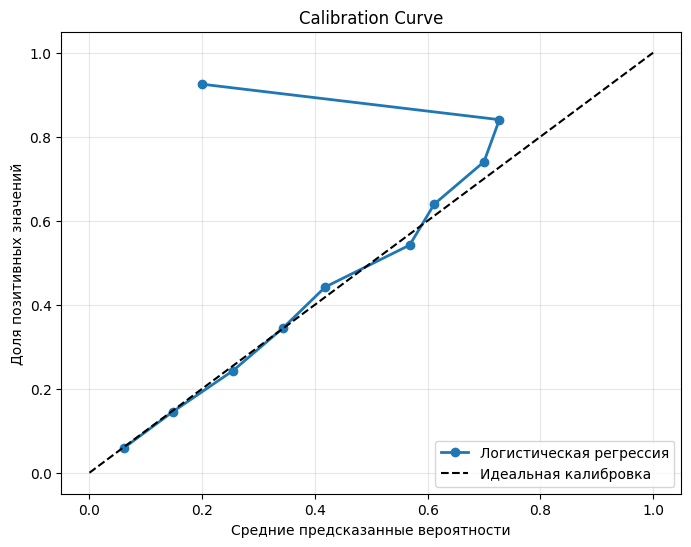

In [139]:
# Визуализация для логистической регрессии

plt.figure(figsize=(8, 6))
plt.plot(prob_true_lr, prob_pred_lr, marker='o', linewidth=2, label='Логистическая регрессия')
plt.plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка')
plt.xlabel('Средние предсказанные вероятности')
plt.ylabel('Доля позитивных значений')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

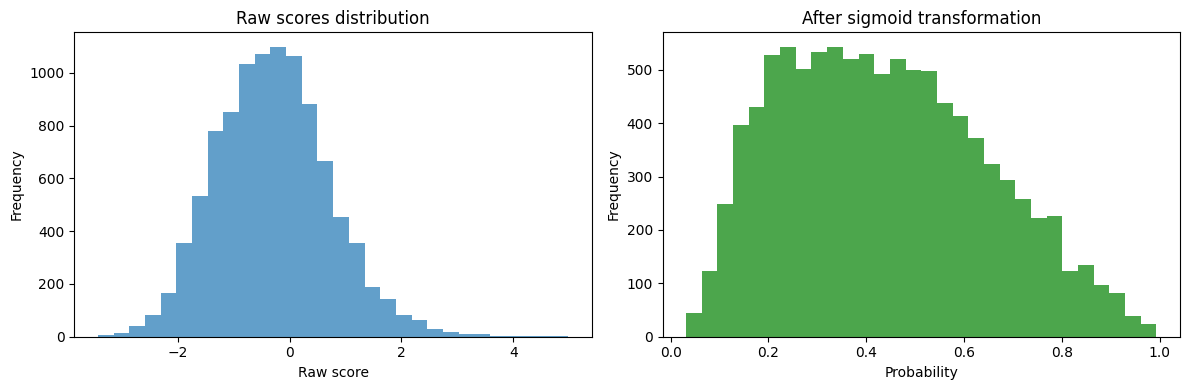

In [140]:
# Визуализация сигмоиды
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(raw_scores, bins=30, alpha=0.7)
plt.title('Raw scores distribution')
plt.xlabel('Raw score')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(probs_standard, bins=30, alpha=0.7, color='green')
plt.title('After sigmoid transformation')
plt.xlabel('Probability')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

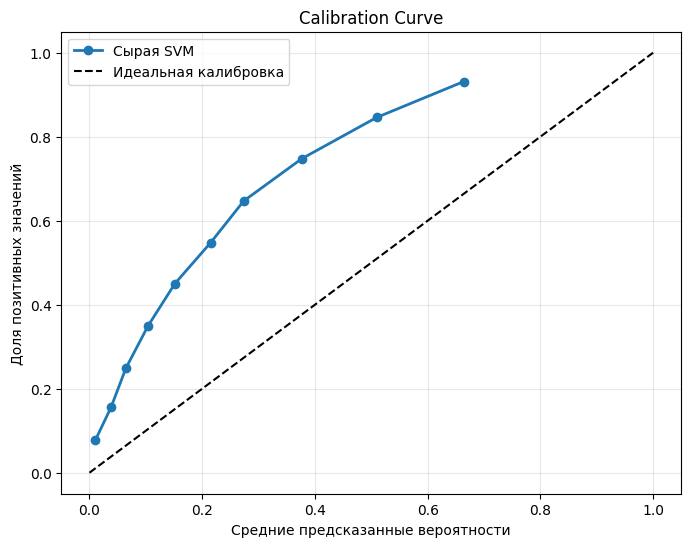

In [141]:
# Калибровочная кривая для SVC 

plt.figure(figsize=(8, 6))
plt.plot(prob_true_svm, prob_pred_svm, marker='o', linewidth=2, label='Сырая SVM')
plt.plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка')
plt.xlabel('Средние предсказанные вероятности')
plt.ylabel('Доля позитивных значений')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 9.2 Применение методов калибровки

In [142]:
# Будем применять CalibratedClassifierCV с методом 'isotonic' на отдельной калибровочной выборке

# Замораживаем обученную лучшую модель логистической регрессии

frozen_lr = FrozenEstimator(final_pipeline_lr)

# Замораживаем обученную лучшую модель SVC

frozen_svm = FrozenEstimator(best_estimator_svc)


In [143]:
# Применим калибровщик к логистической регрессии и SVC моделям на отдельной выборке X_calib, y_calib

# Логистическая регрессия

calibrator_lr = CalibratedClassifierCV(
    estimator=frozen_lr,
    method='isotonic')

calibrator_lr.fit(X_calib_fin, y_calib)

final_lr_calibrated = calibrator_lr.predict_proba(X_test_fin)[:, 1] 

In [144]:
# SVC модель

calibrator_svm = CalibratedClassifierCV(
    estimator=frozen_svm,
    method='isotonic')

calibrator_svm.fit(X_calib_fin, y_calib)

final_svm_calibrated = calibrator_svm.predict_proba(X_test_fin)[:, 1] 

#### 9.3 Модели до и после калибровки

In [145]:
# Расчитаем оценку Бриера после калибровки обоих моделей. Оценка ДО хранится в переменных brier_lr и brier_svm

# Логистическая
brier_lr_calib = brier_score_loss(y_test, final_lr_calibrated)
print(f"Оценка Бриера для неоткалиброванной логистической регрессии:  {brier_lr}, для откалиброванной: {brier_lr_calib}")

Оценка Бриера для неоткалиброванной логистической регрессии:  0.12480158522071746, для откалиброванной: 0.12546095645928823


In [146]:
# SVM

brier_svm_calib = brier_score_loss(y_test, final_svm_calibrated)
print(f"Оценка Бриера для неоткалиброванной SVM модели:  {brier_svm}, для откалиброванной: {brier_svm_calib}")

Оценка Бриера для неоткалиброванной SVM модели:  0.12467872056472641, для откалиброванной: 0.1256269264031296


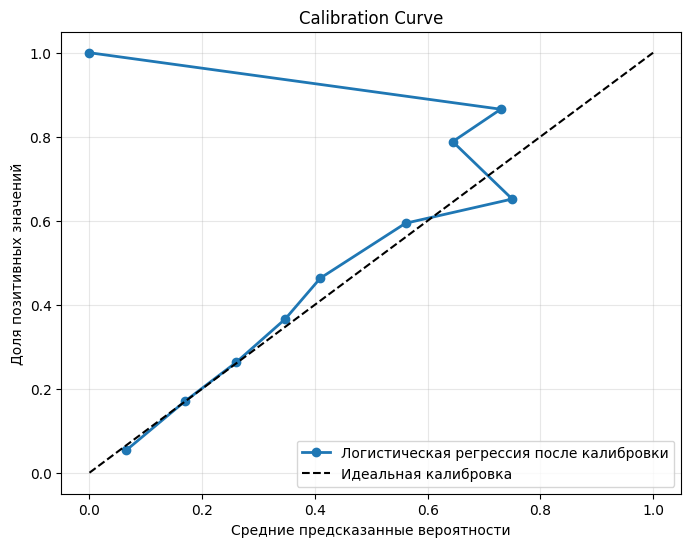

In [147]:
# Строим калибровочную кривую для модели логистической регрессии после калибровки

prob_true_lr_calib, prob_pred_lr_calib = calibration_curve(y_test, final_lr_calibrated, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_true_lr_calib, prob_pred_lr_calib, marker='o', linewidth=2, label='Логистическая регрессия после калибровки')
plt.plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка')
plt.xlabel('Средние предсказанные вероятности')
plt.ylabel('Доля позитивных значений')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

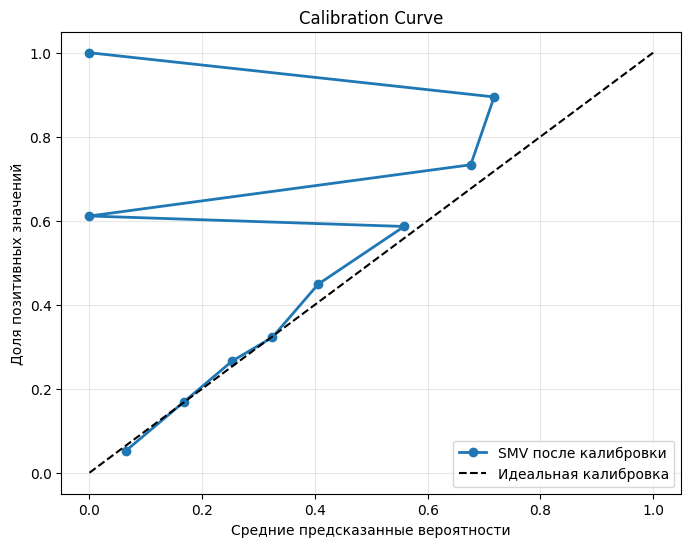

In [148]:
# Строим калибровочную кривую для модели SVM после калибровки

prob_true_svm_calib, prob_pred_svm_calib = calibration_curve(y_test, final_svm_calibrated, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_true_svm_calib, prob_pred_svm_calib, marker='o', linewidth=2, label='SMV после калибровки')
plt.plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка')
plt.xlabel('Средние предсказанные вероятности')
plt.ylabel('Доля позитивных значений')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки

#### 10.2 Сравните модели до и после калибровки

#### 10.1 Метрики калибровки

Рассчитаем и выведем метрики калибровки

In [149]:
print(f"Оценка Бриера для неоткалиброванной логистической регрессии:  {brier_lr}, для откалиброванной: {brier_lr_calib}")
print(f"Оценка Бриера для неоткалиброванной SVM модели:  {brier_svm}, для откалиброванной: {brier_svm_calib}")

Оценка Бриера для неоткалиброванной логистической регрессии:  0.12480158522071746, для откалиброванной: 0.12546095645928823
Оценка Бриера для неоткалиброванной SVM модели:  0.12467872056472641, для откалиброванной: 0.1256269264031296


In [150]:
# Расчитаем метрики ECE и MCE для моделей

# Функция для расчета ЕСЕ
def calculate_ece(y_true, y_prob, n_bins=10):

    # Создаем границы бинов
    bins = np.linspace(0, 1, n_bins + 1)
    
    ece = 0  # Инициализируем общую ошибку калибровки.
    n = len(y_true)  # Общее количество примеров.
    
    # Итерируемся по каждому бину.
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        # Создаем логическую маску для отбора примеров, которые попадают в текущий бин.
        # Последний бин (i == n_bins - 1) включает правую границу, чтобы захватить
        # вероятность 1.0, остальные - нет.
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        
        # Проверяем, есть ли в текущем бине хотя бы один пример.
        if np.sum(mask) > 0:
            bin_size = np.sum(mask)
            
            # Вычисляем среднюю предсказанную уверенность (confidence) для бина.
            bin_conf = np.mean(y_prob[mask])
            
            # Вычисляем среднюю точность (долю правильных ответов) в этом бине.
            bin_acc = np.mean(y_true[mask])
            
            # Вычисляем вклад текущего бина в общую ошибку.
            # Это абсолютная разница, умноженная на количество примеров в бине.
            contribution = np.abs(bin_conf - bin_acc) * bin_size
            ece += contribution
            
    # Возвращаем итоговое значение ECE, нормированное на общее количество примеров.
    return ece / n

In [151]:
# Функция для расчета MCE 

def calculate_mce(y_true, y_prob, n_bins=10):
 
    # Создаем границы бинов от 0 до 1
    bins = np.linspace(0, 1, n_bins + 1)
    
    # Инициализируем максимальную ошибку нулем.
    max_error = 0
    
    # Итерируемся по каждому бину.
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        # Создаем логическую маску, чтобы выбрать объекты,
        # чьи вероятности попадают в текущий бин.
        # Последний бин включает верхнюю границу (1.0).
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)

        # Продолжаем, только если в бине есть хотя бы один объект.
        if np.sum(mask) > 0:
            # Вычисляем среднюю уверенность модели для этого бина.
            bin_conf = np.mean(y_prob[mask])

            # Вычисляем среднюю точность (долю правильных ответов) в этом бине.
            bin_acc = np.mean(y_true[mask]) 

            # Вычисляем абсолютную разницу между точностью и уверенностью.
            diff = np.abs(bin_conf - bin_acc)

            # Обновляем максимальную ошибку, если текущая разница больше.
            max_error = max(max_error, diff)
            
    # Возвращаем наибольшую найденную разницу.
    return max_error

In [152]:
# Расчет метрик для неоткалиброванных и откалиброванных моделей

#ECE некалиброванные
ECE_LR = calculate_ece(y_test, y_test_proba_lr)
ECE_SVM = calculate_ece(y_test, probs_standard) # для сырой SVM берем данные, преобразованные через сигмоиду

#MCE некалиброванные
MCE_LR = calculate_mce(y_test, y_test_proba_lr)
MCE_SVM = calculate_mce(y_test, probs_standard) # для сырой SVM берем данные, преобразованные через сигмоиду

In [153]:
#ECE калиброванные
ECE_LR_calib = calculate_ece(y_test, final_lr_calibrated)
ECE_SVM_calib = calculate_ece(y_test, final_svm_calibrated) 

#MCE калиброванные
MCE_LR_calib = calculate_mce(y_test, final_lr_calibrated)
MCE_SVM_calib = calculate_mce(y_test, final_svm_calibrated) 

#### 10.2 Таблица сравнения моделей до и после калибровки

In [154]:
# Создадим словари для метрик
metric_LR_table = {}
metric_SVM_table = {}

# Заполним словари с метриками
metric_LR_table = {
    'Brier_uncalib': brier_lr,
    'Brier_calib': brier_lr_calib,
    'ECE_uncalib': ECE_LR, 
    'ECE_calib': ECE_LR_calib, 
    'MCE_uncalib': MCE_LR,
    'MCE_calib': MCE_LR_calib
}

metric_SVM_table = {
    'Brier_uncalib': brier_svm,
    'Brier_calib': brier_svm_calib,
    'ECE_uncalib': ECE_SVM, 
    'ECE_calib': ECE_SVM_calib, 
    'MCE_uncalib': MCE_SVM,
    'MCE_calib': MCE_SVM_calib
}

In [155]:
metric_df = pd.DataFrame.from_dict({'Logistic_regression': metric_LR_table, 'SVM_model': metric_SVM_table})
print(metric_df)

               Logistic_regression  SVM_model
Brier_uncalib             0.124802   0.124679
Brier_calib               0.125461   0.125627
ECE_uncalib               0.005964   0.264434
ECE_calib                 0.010941   0.011486
MCE_uncalib               0.725050   0.373364
MCE_calib                 1.000000   1.000000


## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

### 11.2 Напишите выводы

### 11.3 Рекомендации

#### 11.1 Общие результаты

In [156]:
# 1. Характеристики Dummy-модели
print(f"Baseline PR-AUC: {baseline['mean']:.4f} (+/- {baseline['std']:.4f})")

Baseline PR-AUC: 0.2407 (+/- 0.0075)


In [157]:
# 2. Характеристики финальной модели

# Логистическая регрессия
print(f"Метрика PR-AUC: {pr_auc_lr}, метрика Бриера {brier_lr}")

# SVM модель
print(f"Метрика PR-AUC: {pr_auc_svm}, метрика Бриера {brier_svm}")

Метрика PR-AUC: 0.392772787305745, метрика Бриера 0.12480158522071746
Метрика PR-AUC: 0.3916821461745283, метрика Бриера 0.12467872056472641


In [158]:
# Метрики до и после калибровки моделей
print('Метрики до и после калибровки моделей')
print(metric_df)

Метрики до и после калибровки моделей
               Logistic_regression  SVM_model
Brier_uncalib             0.124802   0.124679
Brier_calib               0.125461   0.125627
ECE_uncalib               0.005964   0.264434
ECE_calib                 0.010941   0.011486
MCE_uncalib               0.725050   0.373364
MCE_calib                 1.000000   1.000000


##### Топ-5 признаков
По итогу расчетов коэффициентов по моделям SMV и Логистической регрессии выявлены основные признаки, влияющие на модель

1. app_id - идентификатор рекламируемого мобильного приложения
2. site_id - идентификатор веб-сайта, на котором был показан баннер
3. app_category - категория рекламируемого приложения
4. site_category - тематическая категория веб-сайта
5. ml_feature_9 - машинно сгенерированный числовой признак, полученный в результате обработки


#### 11.2 Выводы 

Качество модели по сравнению с базовой улучшилось. 
На вероятность клика больше всего влияет категория и приложения которые попадают в рекламу, а также категория и сайт, на котором показывается баннер.
Калибровка улучшила модель (приблизила к калибровочной кривой) в части малых значений, что может означать, что модель лучше предсказывает отсутствие клика, чем сам клик. В части предсказаний, близких к единице модель недооценивает вероятности.

В текущем виде модель нужно дорабатывать в части определения положительной категории (вероятности клика)

В части улучшения, возможно, стоит подобрать дополнительные признаки, например, блокировщики рекламы на устройствах, провести исследование, не раздражает ли баннеры пользователей, например, перекрывают экран и их стремятся закрыть. Также стоит пересмотреть машинно сгенерированные признаки, их корелляция с целевой переменной не подтверждена, и они усложняют модель

## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

### 12.2 Проверьте работоспособность вашего кода

In [159]:
# Сохраним модель и метаданные с помощью joblib

# Собираем признаки
metadata = {
    'model_version': '2.0',
    'training_date': '2026-02-24',
    'features': columns_to_select
}

In [160]:
# Сохраняем препроцессор, модели логистической регрессии и SVM
joblib.dump({'preprocessor': preprocessor,
             'metadata': metadata,
             'calibratedLR': calibrator_lr,
             'calibratedSVM': calibrator_svm
            },
             'Advandex_click_model 2.0_24.02.26.joblib')

['Advandex_click_model 2.0_24.02.26.joblib']

In [161]:
# Загружаем модель для проверки

loaded_data = joblib.load('Advandex_click_model 2.0_24.02.26.joblib')

loaded_LR = loaded_data['calibratedLR']
loaded_SVM = loaded_data['calibratedSVM']
loaded_preprocessor = loaded_data['preprocessor']

In [162]:
# Проверим применение загруженного препроцессора к тестовым данным

loaded_preprocessor.transform(X_test_fin)

array([[ 0.65822202,  0.08299596, -1.55660428, ...,  0.19794829,
         0.20224116,  0.22494355],
       [ 0.61555252, -0.15595039, -0.55279344, ...,  0.19794829,
         0.20224116,  0.20988601],
       [ 0.77435553,  0.13651386,  0.92985903, ...,  0.19794829,
         0.20224116,  0.16022315],
       ...,
       [-0.6297126 ,  0.266512  ,  1.43975247, ...,  0.19794829,
         0.20224116,  0.2016995 ],
       [ 0.58173896, -0.57466896,  0.87409865, ...,  0.19794829,
         0.20224116,  0.28202691],
       [ 0.98488523, -1.22963772,  1.3772726 , ...,  0.19794829,
         0.20224116,  0.27815641]], shape=(10000, 22))

In [163]:
# Проверим предсказание модели логистической регрессии

loaded_LR_predict = loaded_LR.predict_proba(X_test_fin)[:, 1]

In [164]:
# Проверим предсказание модели SVM

loaded_SVM_predict = loaded_SVM.predict_proba(X_test_fin)[:, 1]

In [165]:
# Посчитаем оценки логистической регрессии и сравним с полученными ранее

brier_loaded_LR_predict = brier_score_loss(y_test, loaded_LR_predict)
print(f"Оценка Бриера по загруженной модели равна: {brier_loaded_LR_predict}, оценка Бриера, полученная ранее: {brier_lr_calib}")

Оценка Бриера по загруженной модели равна: 0.12546095645928823, оценка Бриера, полученная ранее: 0.12546095645928823


In [166]:
# Посчитаем оценки SVM и сравним с полученными ранее

brier_loaded_SVM_predict = brier_score_loss(y_test, loaded_SVM_predict)
print(f"Оценка Бриера по загруженной модели равна: {brier_loaded_SVM_predict}, оценка Бриера, полученная ранее: {brier_svm_calib}")

Оценка Бриера по загруженной модели равна: 0.1256269264031296, оценка Бриера, полученная ранее: 0.1256269264031296
